# Creating WNBA DF

Scraping, unifying, and calculating features in dataset

DO NOT HAVE TO RERUN THIS EVERY TIME - JUST UPLOAD UNIFIED_2021_2025.CSV AND CONTINUE FROM THERE

In [ ]:
# ============================================================
# 0) Setup
# ============================================================
!pip -q install pandas numpy requests python-dateutil tqdm python-dotenv bs4 lxml nba_api

import os
import time
import math
import json
import re
from datetime import datetime, timedelta, date

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 200)

# API keys here
GUARDIAN_API_KEY = os.getenv("GUARDIAN_API_KEY", "32809122-5d7c-417e-92bf-2e2a380c5672")

# Basic polite request settings
DEFAULT_HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; DS112-project/1.0; +https://example.com)",
}
REQUEST_SLEEP_SECONDS = 0.35

def safe_sleep():
    time.sleep(REQUEST_SLEEP_SECONDS)

# ============================================================
# 1) WNBA games (schedule + game ids) via nba_api
# ============================================================
from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.static import teams as nba_teams

def get_wnba_games(season: str, season_type: str = "Regular Season") -> pd.DataFrame:
    """
    Pull WNBA games using nba_api LeagueGameFinder with league_id='10'.
    """
    lgf = leaguegamefinder.LeagueGameFinder(
        league_id_nullable="10",  # WNBA
        season_nullable=season,
        season_type_nullable=season_type,
    )
    df = lgf.get_data_frames()[0].copy()

    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"]).dt.date

    def parse_home_away(row):
        matchup = row["MATCHUP"]
        team_abbr = row["TEAM_ABBREVIATION"]
        if " vs. " in matchup or " vs " in matchup or " vs." in matchup:
            return ("HOME", team_abbr)
        elif " @ " in matchup:
            return ("AWAY", team_abbr)
        return (None, team_abbr)

    df[["HOME_AWAY_FLAG", "TEAM_ABBR_PARSED"]] = df.apply(
        lambda r: pd.Series(parse_home_away(r)), axis=1
    )

    games = []
    for game_id, g in df.groupby("GAME_ID"):
        g = g.copy()
        g_home = g[g["HOME_AWAY_FLAG"] == "HOME"]
        g_away = g[g["HOME_AWAY_FLAG"] == "AWAY"]

        if len(g_home) != 1 or len(g_away) != 1:
            continue

        home = g_home.iloc[0]
        away = g_away.iloc[0]

        games.append({
            "game_id": game_id,
            "game_date": home["GAME_DATE"],
            "season": season,
            "home_team_abbr": home["TEAM_ABBREVIATION"],
            "away_team_abbr": away["TEAM_ABBREVIATION"],
            "home_team_name": home["TEAM_NAME"],
            "away_team_name": away["TEAM_NAME"],
            "home_points": home["PTS"],
            "away_points": away["PTS"],
            "home_win": 1 if home["WL"] == "W" else 0,
        })

    games_df_five_years = pd.DataFrame(games).sort_values(["game_date", "game_id"]).reset_index(drop=True)
    return games_df_five_years


# Pull seasons 2021, 2022, 2023, 2024, and 2025 regular season
print("Pulling games from NBA API...")
games_2021 = get_wnba_games("2021", "Regular Season")
games_2022 = get_wnba_games("2022", "Regular Season")
games_2023 = get_wnba_games("2023", "Regular Season")
games_2024 = get_wnba_games("2024", "Regular Season")
games_2025 = get_wnba_games("2025", "Regular Season")

games_df_five_years = pd.concat([games_2021, games_2022, games_2023, games_2024, games_2025], ignore_index=True)
print("Shape of combined games:", games_df_five_years.shape)

# ============================================================
# 3) Guardian API: article ingestion and attention metrics
# ============================================================
GUARDIAN_SEARCH_URL = "https://content.guardianapis.com/search"

def guardian_search(query: str, from_date: str, to_date: str, page_size: int = 200, max_pages: int = 50) -> pd.DataFrame:
    """
    Pull Guardian articles for a query in a date range.
    """
    if not GUARDIAN_API_KEY or "PASTE_" in GUARDIAN_API_KEY:
        raise ValueError("Set GUARDIAN_API_KEY first.")

    rows = []
    page = 1
    while page <= max_pages:
        params = {
            "api-key": GUARDIAN_API_KEY,
            "q": query,
            "from-date": from_date,
            "to-date": to_date,
            "page": page,
            "page-size": page_size,
            "order-by": "newest",
            "show-fields": "headline,trailText,bodyText,byline,publication",
            "show-tags": "keyword,contributor",
        }
        safe_sleep()
        r = requests.get(GUARDIAN_SEARCH_URL, params=params, headers=DEFAULT_HEADERS, timeout=30)
        r.raise_for_status()
        data = r.json()
        resp = data.get("response", {})
        results = resp.get("results", [])
        if not results:
            break

        for item in results:
            fields = item.get("fields", {}) or {}
            tags = item.get("tags", []) or []
            rows.append({
                "source": "guardian",
                "article_id": item.get("id"),
                "web_url": item.get("webUrl"),
                "section_name": item.get("sectionName"),
                "type": item.get("type"),
                "pub_date": item.get("webPublicationDate"),
                "headline": fields.get("headline"),
                "trailText": fields.get("trailText"),
                "bodyText": fields.get("bodyText"),
                "byline": fields.get("byline"),
                "keywords": [t.get("webTitle") for t in tags if t.get("type") == "keyword"],
                "contributors": [t.get("webTitle") for t in tags if t.get("type") == "contributor"],
                "query_used": query,
            })

        pages_total = resp.get("pages")
        if pages_total is not None and page >= pages_total:
            break
        page += 1

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    df["pub_date"] = pd.to_datetime(df["pub_date"], errors="coerce")
    df["date"] = df["pub_date"].dt.date
    return df

def build_attention_features(
    games: pd.DataFrame,
    articles: pd.DataFrame,
    window_days: int = 7,
    label: str = "guardian_attention_7d",
) -> pd.DataFrame:
    """
    For each game, count articles mentioning the query in the window_days before game_date.
    """
    out = games.copy()
    if articles.empty:
        out[label] = 0
        return out

    articles_by_date = articles.groupby("date").size().to_dict()

    def count_in_window(game_date: date) -> int:
        total = 0
        for i in range(1, window_days + 1):
            d = game_date - timedelta(days=i)
            total += int(articles_by_date.get(d, 0))
        return total

    out[label] = out["game_date"].apply(count_in_window)
    return out


# Determine date bounds based on games
min_date = games_df_five_years["game_date"].min()
max_date = games_df_five_years["game_date"].max()
from_date = str(min_date - timedelta(days=30))
to_date = str(max_date)

# 1. Search for Caitlin Clark
print("Fetching articles for Caitlin Clark...")
guardian_clark = guardian_search(
    query='"Caitlin Clark" AND (WNBA OR "Indiana Fever" OR Fever)',
    from_date=from_date,
    to_date=to_date
)

# 2. Search for Angel Reese
print("Fetching articles for Angel Reese...")
guardian_reese = guardian_search(
    query='"Angel Reese" AND (WNBA OR "Chicago Sky" OR Sky)',
    from_date=from_date,
    to_date=to_date
)

# 3. Search for Cameron Brink
print("Fetching articles for Cameron Brink...")
guardian_brink = guardian_search(
    query='"Cameron Brink" AND (WNBA OR "Los Angeles Sparks" OR Sparks)',
    from_date=from_date,
    to_date=to_date
)

# Append features to dataframe
games_df_five_years = build_attention_features(games_df_five_years, guardian_clark, window_days=7, label="clark_guardian_articles_7d")
games_df_five_years = build_attention_features(games_df_five_years, guardian_reese, window_days=7, label="reese_guardian_articles_7d")
games_df_five_years = build_attention_features(games_df_five_years, guardian_brink, window_days=7, label="brink_guardian_articles_7d")

# View final dataset output
games_df_five_years

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.5 MB/s eta 0:00:00
Pulling games from NBA API...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import re

def _norm_team(s: str) -> str:
    """Normalize team names to allow for a perfect match during merging."""
    s = (s or '').lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def generate_unified_five_years(games_df_five_years, attendance_csv_path):
    # 1. Setup Basic Columns
    df = games_df_five_years.copy()
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    df["game_date"] = pd.to_datetime(df["game_date"])
    df["away_win"] = 1 - df["home_win"]

    # 2. Process Attendance Data
    att_df = pd.read_csv(attendance_csv_path)

    # Construct an exact date from the three separate columns in your CSV
    date_str = (
        att_df["Year"].astype(str).str.strip() + " " +
        att_df["Month"].astype(str).str.strip() + " " +
        att_df["Day"].astype(str).str.strip()
    )
    att_df["game_date"] = pd.to_datetime(date_str, errors="coerce")

    # Clean the attendance commas and convert to numeric
    att_df["Attendance"] = (
        att_df["Attendance"].astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    att_df["Attendance"] = pd.to_numeric(att_df["Attendance"], errors="coerce")

    # Standardize names for the merge
    att_df["team_norm"] = att_df["Home Team"].map(_norm_team)
    att_df["opp_norm"] = att_df["Away Team"].map(_norm_team)
    df["home_norm"] = df["home_team_name"].map(_norm_team)
    df["away_norm"] = df["away_team_name"].map(_norm_team)

    # 3. Merge Attendance onto the main dataframe
    cols_to_pull = [
        "game_date", "team_norm", "opp_norm",
        "Year", "Day of Week", "Month", "Day", "Time (ET)",
        "Game Type", "Arena", "City", "State", "Attendance"
    ]

    # Inner merge automatically drops games that don't match between API and CSV
    df = df.merge(
        att_df[cols_to_pull],
        left_on=["game_date", "home_norm", "away_norm"],
        right_on=["game_date", "team_norm", "opp_norm"],
        how="inner"
    ).drop(columns=["team_norm", "opp_norm", "home_norm", "away_norm"])

    # Rename columns to standard, python-friendly snake_case names
    df.rename(columns={
        "Year": "year",
        "Day of Week": "day_of_week",
        "Month": "month",
        "Day": "day",
        "Time (ET)": "time_et",
        "Game Type": "game_type",
        "Arena": "arena",
        "City": "city",
        "State": "state",
        "Attendance": "attendance"
    }, inplace=True)

    # 4. Calculate Win Percentages (Pre-Game stats to prevent Data Leakage)
    h_games = df[["game_date", "home_team_name", "home_win"]].rename(columns={"home_team_name": "team", "home_win": "win"})
    a_games = df[["game_date", "away_team_name", "away_win"]].rename(columns={"away_team_name": "team", "away_win": "win"})

    team_history = pd.concat([h_games, a_games], ignore_index=True).sort_values(["team", "game_date"])

    team_history["games_played_before"] = team_history.groupby("team").cumcount()
    team_history["wins_before_game"] = team_history.groupby("team")["win"].cumsum() - team_history["win"]

    team_history["win_pct"] = (
        team_history["wins_before_game"] /
        team_history["games_played_before"].replace(0, 1)
    )

    # Map pre-game win percentages back to the big dataframe
    df = df.merge(
        team_history[["game_date", "team", "win_pct"]].rename(columns={"team": "home_team_name", "win_pct": "home_win_pct"}),
        on=["game_date", "home_team_name"], how="inner"
    )
    df = df.merge(
        team_history[["game_date", "team", "win_pct"]].rename(columns={"team": "away_team_name", "win_pct": "opponent_win_pct"}),
        on=["game_date", "away_team_name"], how="inner"
    )

    # 5. Feature Engineering: Market, Arena, and Time
    df["day_of_week"] = df["day_of_week"].fillna(df["game_date"].dt.day_name())
    df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

    market_size_map = {
        "Atlanta Dream": 6400000, "Chicago Sky": 9500000, "Connecticut Sun": 1200000,
        "Dallas Wings": 7600000, "Golden State Valkyries": 7700000, "Indiana Fever": 2100000,
        "Las Vegas Aces": 2300000, "Los Angeles Sparks": 13000000, "Minnesota Lynx": 3700000,
        "New York Liberty": 20000000, "Phoenix Mercury": 5000000, "Seattle Storm": 4000000,
        "Washington Mystics": 6300000
    }

    # Audited and Corrected Basketball Capacities
    arena_capacity_map = {
        "Barclays Center": 17732,
        "Gateway Center Arena @ College Park": 3500,
        "Target Center": 18978,
        "Entertainment and Sports Arena": 4200,
        "CareFirst Arena": 4200,
        "Capital One Arena": 20356,
        "Angel of the Winds Arena": 8500,
        "Mohegan Sun Arena": 9323,
        "TD Garden": 19156,
        "Phoenix Suns Arena": 17071,
        "Footprint Center": 17071,
        "PHX Arena": 17071,
        "Mortgage Matchup Center": 17071,
        "Michelob ULTRA Arena": 12000,
        "T-Mobile Arena": 18000,
        "College Park Center": 7000,
        "Wintrust Arena": 10387,
        "United Center": 20917,
        "Los Angeles Convention Center": 1200,
        "STAPLES Center": 19067,
        "Crypto.com Arena": 19067,
        "Galen Center": 10258,
        "Walter Pyramid at Long Beach State": 4200,
        "Grand Canyon University Arena": 7000,
        "Desert Financial Arena": 14198,
        "Climate Pledge Arena": 18100,
        "Gainbridge Fieldhouse": 17274,
        "Indiana Farmers Coliseum": 6800,
        "Hinkle Fieldhouse": 9100,
        "State Farm Arena": 16888,
        "Chase Center": 18064,
        "CFG Bank Arena": 14000,
        "American Airlines Center": 19200,
        "EagleBank Arena": 10000,
        "Rogers Arena": 19700,
        "SAP Center": 17562
    }

    df["market_size"] = df["home_team_name"].map(market_size_map)
    df["base_arena_capacity"] = df["arena"].map(arena_capacity_map)

    # Calculate fill rate using the dynamically looked up arena capacity
    df["arena_fill_rate"] = df["attendance"] / df["base_arena_capacity"]

    return df

# Build the 5-Year Dataframe
unified_df_five_years = generate_unified_five_years(games_df_five_years, "Filtered WNBA Game Attendance.csv")

# Print to verify the results
print(f"Total rows in clean dataset: {len(unified_df_five_years)}")
unified_df_five_years

In [ ]:
unified_df_five_years.to_csv("unified_2021_2025.csv")

# Train on 2022-2023

Fitting a model to the league performance before the star players entered

Comparing different models and different feature inputs with SFS, GridSearch, and cross-validation

In [ ]:
# =========================================================
# WNBA FIRST
# =========================================================

import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Load the new dataset
unified_df_five_years = pd.read_csv('/content/unified_2021_2025.csv')
unified_df_five_years['season'] = unified_df_five_years['season'].astype(str)

# Isolate PRE-BREAKOUT for Cross Validation
df_pb = unified_df_five_years[unified_df_five_years['season'].isin(["2022", "2023"])].copy()

# =========================================================
# FEATURE ENGINEERING & CAPACITY CORRECTIONS
# =========================================================

# A. Fix the 2022 Fever Arena Capacities (Do NOT drop the games!)
# Update capacity for games played at the Coliseum
df_pb.loc[df_pb['arena'].str.contains('Coliseum', na=False), 'base_arena_capacity'] = 6800
# Update capacity for games played at Hinkle Fieldhouse
df_pb.loc[df_pb['arena'].str.contains('Hinkle', na=False), 'base_arena_capacity'] = 9100

# B. Create 'is_camp_day'
# A Camp Day is a weekday game (Mon-Fri) played between 10 AM and 3 PM.
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
camp_time_pattern = '10:.*AM|11:.*AM|12:.*PM|1:.*PM|2:.*PM|3:.*PM'

df_pb['is_camp_day'] = (
    (df_pb['day_of_week'].isin(weekdays)) &
    (df_pb['time_et'].str.contains(camp_time_pattern, na=False))
).astype(int)

# C. Define Features (Removed collinear variables like city, state, and raw time_et)
num_features = ['market_size', 'base_arena_capacity', 'opponent_win_pct', 'home_win_pct']
cat_features = ['season', 'home_team_name', 'away_team_name', 'day_of_week', 'is_weekend', 'is_camp_day']

X_train = df_pb[num_features + cat_features]
y_train = df_pb['attendance']

avg_attendance_pb = y_train.mean()
print(f"Pre-Breakout Games Count: {len(df_pb)} (No games dropped!)")
print(f"P-B Average Attendance: {avg_attendance_pb:.2f}")
print("=" * 60)

# 2. Preprocess the Data Once
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)
X_train_preprocessed = preprocessor.fit_transform(X_train)
total_encoded_features = X_train_preprocessed.shape[1]
all_feature_names = preprocessor.get_feature_names_out()

# 3. Define the Models, Fast SFS Models, and Hyperparameter Distributions
models = {
    "KNN": {
        "model": TransformedTargetRegressor(
            regressor=KNeighborsRegressor(),
            func=np.log, inverse_func=np.exp
        ),
        "sfs_model": TransformedTargetRegressor(
            regressor=KNeighborsRegressor(n_neighbors=5),
            func=np.log, inverse_func=np.exp
        ),
        "params": {
            'regressor__n_neighbors': [3, 5, 7, 10, 15, 20],
            'regressor__weights': ['uniform', 'distance'],
            'regressor__p': [1, 2]
        }
    },
    "XGBoost": {
        "model": TransformedTargetRegressor(
            regressor=XGBRegressor(random_state=42, objective='reg:squarederror'),
            func=np.log, inverse_func=np.exp
        ),
        "sfs_model": TransformedTargetRegressor(
            regressor=XGBRegressor(n_estimators=25, max_depth=3, random_state=42, objective='reg:squarederror', n_jobs=-1),
            func=np.log, inverse_func=np.exp
        ),
        "params": {
            'regressor__n_estimators': [50, 100, 200, 300],
            'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'regressor__max_depth': [3, 5, 7, 10],
            'regressor__subsample': [0.8, 1.0],
            'regressor__colsample_bytree': [0.8, 1.0]
        }
    },
    "Random Forest": {
        "model": TransformedTargetRegressor(
            regressor=RandomForestRegressor(random_state=42),
            func=np.log, inverse_func=np.exp
        ),
        "sfs_model": TransformedTargetRegressor(
            regressor=RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42, n_jobs=-1),
            func=np.log, inverse_func=np.exp
        ),
        "params": {
            'regressor__n_estimators': [100, 200, 300, 500],
            'regressor__max_depth': [None, 5, 10, 15, 20],
            'regressor__min_samples_split': [2, 5, 10],
            'regressor__min_samples_leaf': [1, 2, 4]
        }
    }
}

best_overall_rmse = float('inf')
best_overall_setup = {}

# 4. Run SFS and Randomized Search for Each Model
for model_name, config in models.items():
    print(f"\n--- Processing {model_name} ---")

    # Step A: Sequential Feature Selection using the FAST model
    sfs = SequentialFeatureSelector(
        estimator=config["sfs_model"],
        direction='forward',
        cv=2,
        n_jobs=-1
    )

    print("Selecting best features (Optimized for speed)...")
    X_train_selected = sfs.fit_transform(X_train_preprocessed, y_train)

    # Extract EXACTLY WHICH features were kept
    selected_mask = sfs.get_support()
    kept_feature_names = all_feature_names[selected_mask]
    features_kept_count = len(kept_feature_names)

    # Step B: Randomized Search CV using the FULL model
    print("Tuning hyperparameters...")
    random_search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=15,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train_selected, y_train)
    rmse = np.sqrt(-random_search.best_score_)

    print(f"Best RMSE: {rmse:.2f}")
    print(f"Features Kept ({features_kept_count}/{total_encoded_features}):")
    for f in kept_feature_names:
        print(f"  - {f}")

    print(f"Best Params: {random_search.best_params_}")

    # Track the ultimate winner
    if rmse < best_overall_rmse:
        best_overall_rmse = rmse
        best_overall_setup = {
            "Model": model_name,
            "RMSE": rmse,
            "Features Kept Count": f"{features_kept_count}/{total_encoded_features}",
            "Selected Features List": kept_feature_names,
            "Params": random_search.best_params_,
            "SFS_Object": sfs
        }

print("\n" + "=" * 60)
print("OVERALL BEST MODEL (P-B)")
print("=" * 60)
print(f"Model: {best_overall_setup['Model']}")
print(f"CV RMSE: {best_overall_setup['RMSE']:.2f}")
print(f"RMSE / Avg Ratio: { (best_overall_setup['RMSE'] / avg_attendance_pb):.3f}")
print(f"Count of Features Kept: {best_overall_setup['Features Kept Count']}")
print("Exact Features Kept:")
for feat in best_overall_setup['Selected Features List']:
    print(f"  > {feat}")
print(f"Hyperparameters: {best_overall_setup['Params']}")

Pre-Breakout Games Count: 456 (No games dropped!)
P-B Average Attendance: 6155.91

--- Processing KNN ---
Selecting best features (Optimized for speed)...
Tuning hyperparameters...
Best RMSE: 1667.49
Features Kept (20/41):
  - num__base_arena_capacity
  - num__home_win_pct
  - cat__season_2022
  - cat__season_2023
  - cat__home_team_name_Chicago Sky
  - cat__home_team_name_Indiana Fever
  - cat__home_team_name_Minnesota Lynx
  - cat__home_team_name_Phoenix Mercury
  - cat__home_team_name_Washington Mystics
  - cat__away_team_name_Chicago Sky
  - cat__away_team_name_Los Angeles Sparks
  - cat__away_team_name_Minnesota Lynx
  - cat__away_team_name_Phoenix Mercury
  - cat__away_team_name_Washington Mystics
  - cat__day_of_week_Friday
  - cat__day_of_week_Saturday
  - cat__day_of_week_Tuesday
  - cat__is_weekend_0
  - cat__is_camp_day_0
  - cat__is_camp_day_1
Best Params: {'regressor__weights': 'uniform', 'regressor__p': 1, 'regressor__n_neighbors': 5}

--- Processing XGBoost ---
Selecting

Identified XGBoost as the best with RMSE of 1590 - using it for predictions going forward

# JUMP TO HERE TO RUN FULL PIPELINE

XGBoost Only (use for speed)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Load the new dataset
unified_df_five_years = pd.read_csv('/content/unified_2021_2025.csv')
unified_df_five_years['season'] = unified_df_five_years['season'].astype(str)

# Isolate PRE-BREAKOUT for Cross Validation
df_pb = unified_df_five_years[unified_df_five_years['season'].isin(["2022", "2023"])].copy()

# =========================================================
# FEATURE ENGINEERING & CAPACITY CORRECTIONS
# =========================================================

# A. Fix the 2022 Fever Arena Capacities (Do NOT drop the games!)
# Update capacity for games played at the Coliseum
df_pb.loc[df_pb['arena'].str.contains('Coliseum', na=False), 'base_arena_capacity'] = 6800
# Update capacity for games played at Hinkle Fieldhouse
df_pb.loc[df_pb['arena'].str.contains('Hinkle', na=False), 'base_arena_capacity'] = 9100

# B. Create 'is_camp_day'
# A Camp Day is a weekday game (Mon-Fri) played between 10 AM and 3 PM.
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
camp_time_pattern = '10:.*AM|11:.*AM|12:.*PM|1:.*PM|2:.*PM|3:.*PM'

df_pb['is_camp_day'] = (
    (df_pb['day_of_week'].isin(weekdays)) &
    (df_pb['time_et'].str.contains(camp_time_pattern, na=False))
).astype(int)

# C. Define Features (Removed collinear variables like city, state, and raw time_et)
num_features = ['market_size', 'base_arena_capacity', 'opponent_win_pct', 'home_win_pct']
cat_features = ['season', 'home_team_name', 'away_team_name', 'day_of_week', 'is_weekend', 'is_camp_day']

X_train = df_pb[num_features + cat_features]
y_train = df_pb['attendance']

avg_attendance_pb = y_train.mean()
print(f"Pre-Breakout Games Count: {len(df_pb)} (No games dropped!)")
print(f"P-B Average Attendance: {avg_attendance_pb:.2f}")
print("=" * 60)

# 2. Preprocess the Data Once
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)
X_train_preprocessed = preprocessor.fit_transform(X_train)
total_encoded_features = X_train_preprocessed.shape[1]
all_feature_names = preprocessor.get_feature_names_out()

# 3. Define the Models, Fast SFS Models, and Hyperparameter Distributions
models = {
    "XGBoost": {
        "model": TransformedTargetRegressor(
            regressor=XGBRegressor(random_state=42, objective='reg:squarederror'),
            func=np.log, inverse_func=np.exp
        ),
        "sfs_model": TransformedTargetRegressor(
            regressor=XGBRegressor(n_estimators=25, max_depth=3, random_state=42, objective='reg:squarederror', n_jobs=-1),
            func=np.log, inverse_func=np.exp
        ),
        "params": {
            'regressor__n_estimators': [50, 100, 200, 300],
            'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'regressor__max_depth': [3, 5, 7, 10],
            'regressor__subsample': [0.8, 1.0],
            'regressor__colsample_bytree': [0.8, 1.0]
        }
    }
}

best_overall_rmse = float('inf')
best_overall_setup = {}

# 4. Run SFS and Randomized Search for Each Model
for model_name, config in models.items():
    print(f"\n--- Processing {model_name} ---")

    # Step A: Sequential Feature Selection using the FAST model
    sfs = SequentialFeatureSelector(
        estimator=config["sfs_model"],
        direction='forward',
        cv=2,
        n_jobs=-1
    )

    print("Selecting best features (Optimized for speed)...")
    X_train_selected = sfs.fit_transform(X_train_preprocessed, y_train)

    # Extract EXACTLY WHICH features were kept
    selected_mask = sfs.get_support()
    kept_feature_names = all_feature_names[selected_mask]
    features_kept_count = len(kept_feature_names)

    # Step B: Randomized Search CV using the FULL model
    print("Tuning hyperparameters...")
    random_search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=15,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train_selected, y_train)
    rmse = np.sqrt(-random_search.best_score_)

    print(f"Best RMSE: {rmse:.2f}")
    print(f"Features Kept ({features_kept_count}/{total_encoded_features}):")
    for f in kept_feature_names:
        print(f"  - {f}")

    print(f"Best Params: {random_search.best_params_}")

    # Track the ultimate winner
    if rmse < best_overall_rmse:
        best_overall_rmse = rmse
        best_overall_setup = {
            "Model": model_name,
            "RMSE": rmse,
            "Features Kept Count": f"{features_kept_count}/{total_encoded_features}",
            "Selected Features List": kept_feature_names,
            "Params": random_search.best_params_,
            "SFS_Object": sfs
        }

Pre-Breakout Games Count: 456 (No games dropped!)
P-B Average Attendance: 6155.91

--- Processing XGBoost ---
Selecting best features (Optimized for speed)...
Tuning hyperparameters...
Best RMSE: 1590.89
Features Kept (20/41):
  - num__base_arena_capacity
  - cat__season_2022
  - cat__season_2023
  - cat__home_team_name_Atlanta Dream
  - cat__home_team_name_Los Angeles Sparks
  - cat__home_team_name_Minnesota Lynx
  - cat__home_team_name_New York Liberty
  - cat__home_team_name_Phoenix Mercury
  - cat__away_team_name_Atlanta Dream
  - cat__away_team_name_Chicago Sky
  - cat__away_team_name_Las Vegas Aces
  - cat__away_team_name_Los Angeles Sparks
  - cat__away_team_name_New York Liberty
  - cat__day_of_week_Friday
  - cat__day_of_week_Thursday
  - cat__day_of_week_Tuesday
  - cat__is_weekend_0
  - cat__is_weekend_1
  - cat__is_camp_day_0
  - cat__is_camp_day_1
Best Params: {'regressor__subsample': 1.0, 'regressor__n_estimators': 300, 'regressor__max_depth': 3, 'regressor__learning_rate

In [ ]:
df_pb_wnba = df_pb.copy()

In [ ]:
# =========================================================
# NOW NBA - STARTING FROM 2022-2023 (test) and 2023-2024 (train) CSV files
# =========================================================

In [ ]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# =========================================================
# 1. LOAD 2022-23 NBA DATA
# =========================================================
df_train = pd.read_csv('/content/nba_2022_23_unified.csv')

if 'season' in df_train.columns:
    df_train['season'] = df_train['season'].astype(str)

if 'game_date' in df_train.columns:
    df_train['game_date'] = pd.to_datetime(df_train['game_date'])

# Keep only rows with attendance
df_train = df_train[df_train['attendance'].notna()].copy()

print(f"Training Games Count: {len(df_train)}")
print(f"Training Average Attendance: {df_train['attendance'].mean():.2f}")
print("=" * 60)
df_train = df_train[
    df_train['attendance'].notna() &
    np.isfinite(df_train['attendance']) &
    (df_train['attendance'] > 0) &
    (df_train['attendance'] < 60000)
].copy()

# =========================================================
# 2. FEATURE ENGINEERING
# =========================================================

# Create day_of_week if missing
if 'game_date' in df_train.columns and 'day_of_week' not in df_train.columns:
    df_train['day_of_week'] = df_train['game_date'].dt.day_name()

# Create is_weekend if missing
if 'day_of_week' in df_train.columns and 'is_weekend' not in df_train.columns:
    df_train['is_weekend'] = df_train['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# =========================================================
# 3. DEFINE FEATURES
# =========================================================
# Do NOT include arena_fill_rate because it is target leakage
candidate_num_features = [
    'market_size',
    'arena_capacity',
    'opponent_win_pct',
    'home_win_pct',
    'opponent_popularity'
]

candidate_cat_features = [
    'home_team_name',
    'day_of_week',
    'is_weekend',
    'is_camp_day'
]

# Only keep columns that actually exist
num_features = [col for col in candidate_num_features if col in df_train.columns]
cat_features = [col for col in candidate_cat_features if col in df_train.columns]

print("Numeric features used:", num_features)
print("Categorical features used:", cat_features)

X_train = df_train[num_features + cat_features].copy()
y_train = df_train['attendance'].copy()

avg_attendance_train = y_train.mean()

# =========================================================
# 4. PREPROCESS
# =========================================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
total_encoded_features = X_train_preprocessed.shape[1]
all_feature_names = preprocessor.get_feature_names_out()

# =========================================================
# 5. DEFINE MODELS
# =========================================================
models = {
    "KNN": {
        "model": TransformedTargetRegressor(
            regressor=KNeighborsRegressor(),
            func=np.log,
            inverse_func=np.exp
        ),
        "sfs_model": TransformedTargetRegressor(
            regressor=KNeighborsRegressor(n_neighbors=5),
            func=np.log,
            inverse_func=np.exp
        ),
        "params": {
            'regressor__n_neighbors': [3, 5, 7, 10, 15, 20],
            'regressor__weights': ['uniform', 'distance'],
            'regressor__p': [1, 2]
        }
    },
    "XGBoost": {
        "model": TransformedTargetRegressor(
            regressor=XGBRegressor(
                random_state=42,
                objective='reg:squarederror'
            ),
            func=np.log,
            inverse_func=np.exp
        ),
        "sfs_model": TransformedTargetRegressor(
            regressor=XGBRegressor(
                n_estimators=25,
                max_depth=3,
                random_state=42,
                objective='reg:squarederror',
                n_jobs=-1
            ),
            func=np.log,
            inverse_func=np.exp
        ),
        "params": {
            'regressor__n_estimators': [50, 100, 200, 300],
            'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'regressor__max_depth': [3, 5, 7, 10],
            'regressor__subsample': [0.8, 1.0],
            'regressor__colsample_bytree': [0.8, 1.0]
        }
    },
    "Random Forest": {
        "model": TransformedTargetRegressor(
            regressor=RandomForestRegressor(random_state=42),
            func=np.log,
            inverse_func=np.exp
        ),
        "sfs_model": TransformedTargetRegressor(
            regressor=RandomForestRegressor(
                n_estimators=20,
                max_depth=5,
                random_state=42,
                n_jobs=-1
            ),
            func=np.log,
            inverse_func=np.exp
        ),
        "params": {
            'regressor__n_estimators': [100, 200, 300, 500],
            'regressor__max_depth': [None, 5, 10, 15, 20],
            'regressor__min_samples_split': [2, 5, 10],
            'regressor__min_samples_leaf': [1, 2, 4]
        }
    }
}

best_overall_rmse = float('inf')
best_overall_setup = {}

# =========================================================
# 6. RUN SFS + RANDOMIZED SEARCH ON 2022-23
# =========================================================
for model_name, config in models.items():
    print(f"\n--- Processing {model_name} ---")

    sfs = SequentialFeatureSelector(
        estimator=config["sfs_model"],
        direction='forward',
        cv=2,
        n_jobs=-1
    )

    print("Selecting best features...")
    X_train_selected = sfs.fit_transform(X_train_preprocessed, y_train)

    selected_mask = sfs.get_support()
    kept_feature_names = all_feature_names[selected_mask]
    features_kept_count = len(kept_feature_names)

    print("Tuning hyperparameters...")
    random_search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=15,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train_selected, y_train)
    rmse = np.sqrt(-random_search.best_score_)

    print(f"Best RMSE: {rmse:.2f}")
    print(f"Features Kept ({features_kept_count}/{total_encoded_features}):")
    for f in kept_feature_names:
        print(f"  - {f}")

    print(f"Best Params: {random_search.best_params_}")

    if rmse < best_overall_rmse:
        best_overall_rmse = rmse
        best_overall_setup = {
            "Model": model_name,
            "RMSE": rmse,
            "Features Kept Count": f"{features_kept_count}/{total_encoded_features}",
            "Selected Features List": kept_feature_names,
            "Params": random_search.best_params_,
            "SFS_Object": sfs,
            "Preprocessor": preprocessor
        }

# =========================================================
# 7. FINAL RESULTS
# =========================================================
print("\n" + "=" * 60)
print("OVERALL BEST MODEL (NBA 2022-23 TRAINING)")
print("=" * 60)
print(f"Model: {best_overall_setup['Model']}")
print(f"CV RMSE: {best_overall_setup['RMSE']:.2f}")
print(f"RMSE / Avg Ratio: {(best_overall_setup['RMSE'] / avg_attendance_train):.3f}")
print(f"Count of Features Kept: {best_overall_setup['Features Kept Count']}")
print("Exact Features Kept:")
for feat in best_overall_setup['Selected Features List']:
    print(f"  > {feat}")
print(f"Hyperparameters: {best_overall_setup['Params']}")

Training Games Count: 1274
Training Average Attendance: 17107.17
Numeric features used: ['market_size', 'arena_capacity', 'opponent_win_pct']
Categorical features used: ['home_team_name', 'day_of_week', 'is_weekend']

--- Processing KNN ---
Selecting best features...
Tuning hyperparameters...
Best RMSE: 1640.32
Features Kept (21/42):
  - num__arena_capacity
  - cat__home_team_name_Atlanta Hawks
  - cat__home_team_name_Boston Celtics
  - cat__home_team_name_Brooklyn Nets
  - cat__home_team_name_Charlotte Hornets
  - cat__home_team_name_Chicago Bulls
  - cat__home_team_name_Cleveland Cavaliers
  - cat__home_team_name_Dallas Mavericks
  - cat__home_team_name_Detroit Pistons
  - cat__home_team_name_Golden State Warriors
  - cat__home_team_name_Los Angeles Clippers
  - cat__home_team_name_Milwaukee Bucks
  - cat__home_team_name_Minnesota Timberwolves
  - cat__home_team_name_New Orleans Pelicans
  - cat__home_team_name_Oklahoma City Thunder
  - cat__home_team_name_Orlando Magic
  - cat__home

Identified XGBoost as the best model - use the folowing cell moving forward

In [ ]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# =========================================================
# 1. LOAD NBA DATA
# =========================================================

nba_df = pd.read_csv('/content/nba_2023_24_unified.csv')
nba_df['season'] = nba_df['season'].astype(str)

# Use whatever training years you want here
df_pb_nba = nba_df[nba_df['season'].isin(["2022", "2023"])].copy()

# =========================================================
# 2. OPTIONAL FEATURE ENGINEERING
# =========================================================

# If game_date is present, parse it
df_pb_nba['game_date'] = pd.to_datetime(df_pb_nba['game_date'], errors='coerce')

# Optional: month as a feature
df_pb_nba['game_month'] = df_pb_nba['game_date'].dt.month.astype('Int64').astype(str)

# =========================================================
# 2.5 CLEAN TARGET + FEATURE ROWS
# =========================================================

# Keep only rows where attendance exists and is positive
df_pb_nba = df_pb_nba[df_pb_nba['attendance'].notna()].copy()
df_pb_nba = df_pb_nba[df_pb_nba['attendance'] > 0].copy()

# Optional but recommended:
# drop rows missing required predictor columns
required_cols = [
    'attendance',
    'home_points',
    'away_points',
    'home_win',
    'opponent_win_pct',
    'market_size',
    'arena_capacity',
    'season',
    'home_team_abbr',
    'away_team_abbr',
    'home_team_name',
    'away_team_name',
    'day_of_week',
    'is_weekend',
    'game_month'
]

df_pb_nba = df_pb_nba.dropna(subset=required_cols).copy()

print(f"Rows remaining after cleaning: {len(df_pb_nba)}")
print(f"Missing attendance after cleaning: {df_pb_nba['attendance'].isna().sum()}")
print(f"Nonpositive attendance after cleaning: {(df_pb_nba['attendance'] <= 0).sum()}")
# =========================================================
# 3. DEFINE FEATURES
# =========================================================

target_col = 'attendance'

num_features = [
    'home_points',
    'away_points',
    'home_win',
    'opponent_win_pct',
    'market_size',
    'arena_capacity'
]

cat_features = [
    'season',
    'home_team_abbr',
    'away_team_abbr',
    'home_team_name',
    'away_team_name',
    'day_of_week',
    'is_weekend',
    'game_month'
]

X_train = df_pb_nba[num_features + cat_features]
y_train = df_pb_nba[target_col]

avg_attendance_pb = y_train.mean()
print(f"Pre-Breakout Games Count: {len(df_pb_nba)}")
print(f"Pre-Breakout Average Attendance: {avg_attendance_pb:.2f}")
print("=" * 60)

# =========================================================
# 4. PREPROCESS
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
all_feature_names = preprocessor.get_feature_names_out()
total_encoded_features = X_train_preprocessed.shape[1]

print(f"Total encoded features: {total_encoded_features}")

# =========================================================
# 5. DEFINE XGBOOST MODEL
# =========================================================

xgb_sfs_model = TransformedTargetRegressor(
    regressor=XGBRegressor(
        n_estimators=25,
        max_depth=3,
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    ),
    func=np.log,
    inverse_func=np.exp
)

xgb_model = TransformedTargetRegressor(
    regressor=XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    ),
    func=np.log,
    inverse_func=np.exp
)

param_dist = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7, 10],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

# =========================================================
# 6. SEQUENTIAL FEATURE SELECTION
# =========================================================

print("\nSelecting best features with SFS...")

sfs = SequentialFeatureSelector(
    estimator=xgb_sfs_model,
    direction='forward',
    cv=2,
    n_jobs=-1
)

X_train_selected = sfs.fit_transform(X_train_preprocessed, y_train)

selected_mask = sfs.get_support()
kept_feature_names = all_feature_names[selected_mask]
features_kept_count = len(kept_feature_names)

print(f"Features kept: {features_kept_count}/{total_encoded_features}")
for f in kept_feature_names:
    print(f"  - {f}")

# =========================================================
# 7. HYPERPARAMETER TUNING
# =========================================================

print("\nTuning XGBoost hyperparameters...")

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_selected, y_train)

best_rmse = np.sqrt(-random_search.best_score_)
rmse_ratio = best_rmse / avg_attendance_pb

print("\n" + "=" * 60)
print("FINAL BEST NBA MODEL")
print("Model: XGBoost")
print(f"CV RMSE: {best_rmse:.2f}")
print(f"RMSE / Avg Ratio: {rmse_ratio:.3f}")
print(f"Count of Features Kept: {features_kept_count}/{total_encoded_features}")
print("Best Params:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

# =========================================================
# 8. SAVE BEST SETUP
# =========================================================

best_overall_setup = {
    "Model": "XGBoost",
    "RMSE": best_rmse,
    "RMSE / Avg Ratio": rmse_ratio,
    "Features Kept Count": f"{features_kept_count}/{total_encoded_features}",
    "Selected Features List": kept_feature_names,
    "Selected Feature Mask": selected_mask,
    "Params": random_search.best_params_,
    "SFS_Object": sfs,
    "Preprocessor": preprocessor,
    "Best_Estimator": random_search.best_estimator_
}

Rows remaining after cleaning: 1279
Missing attendance after cleaning: 0
Nonpositive attendance after cleaning: 0
Pre-Breakout Games Count: 1279
Pre-Breakout Average Attendance: 18108.42
Total encoded features: 143

Selecting best features with SFS...
Features kept: 71/143
  - num__opponent_win_pct
  - num__market_size
  - num__arena_capacity
  - cat__season_2023
  - cat__home_team_abbr_Atlanta Hawks
  - cat__home_team_abbr_Boston Celtics
  - cat__home_team_abbr_Brooklyn Nets
  - cat__home_team_abbr_Chicago Bulls
  - cat__home_team_abbr_Cleveland Cavaliers
  - cat__home_team_abbr_Denver Nuggets
  - cat__home_team_abbr_Houston Rockets
  - cat__home_team_abbr_Los Angeles Lakers
  - cat__home_team_abbr_Memphis Grizzlies
  - cat__home_team_abbr_Miami Heat
  - cat__home_team_abbr_Minnesota Timberwolves
  - cat__home_team_abbr_New Orleans Pelicans
  - cat__home_team_abbr_New York Knicks
  - cat__home_team_abbr_Orlando Magic
  - cat__home_team_abbr_Phoenix Suns
  - cat__home_team_abbr_Sacrame

# Test on 2023-2024

Actual Attendance - Predicted Attendance = Residual

As correlated with addition of breakout star players in the league

In [ ]:
# =========================================================
# TEST ON WNBA
# =========================================================

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# =========================================================
# 5. PREDICTING 2024 & 2025: THE SUPERSTAR EXTERNALITY
# =========================================================

# Dictionary of average ticket prices by team and year
wnba_attendance_prices = {
    "Minnesota Lynx": {"2023": 60, "2024": 241},
    "Washington Mystics": {"2023": 79, "2024": 192},
    "Atlanta Dream": {"2023": 80, "2024": 191},
    "New York Liberty": {"2023": 75, "2024": 157},
    "League Average": {"2023": 65, "2024": 155},
    "Dallas Wings": {"2023": 68, "2024": 149},
    "Chicago Sky": {"2023": 58, "2024": 146},
    "Phoenix Mercury": {"2023": 63, "2024": 140},
    "Connecticut Sun": {"2023": 83, "2024": 135},
    "Los Angeles Sparks": {"2023": 39, "2024": 135},
    "Seattle Storm": {"2023": 56, "2024": 131},
    "Indiana Fever": {"2023": 67, "2024": 124},
    "Las Vegas Aces": {"2023": 53, "2024": 123}
}

# 1. Isolate 2024 & 2025 for Predictions
df_future_w = unified_df_five_years[
    (unified_df_five_years['season'].astype(str).isin(["2024", "2025"])) &
    (unified_df_five_years['attendance'].notna()) &
    (unified_df_five_years['attendance'] > 0)
].copy()

# 2. Apply Feature Engineering to Future Data
df_future_w.loc[df_future_w['arena'].str.contains('Coliseum', na=False), 'base_arena_capacity'] = 6800
df_future_w.loc[df_future_w['arena'].str.contains('Hinkle', na=False), 'base_arena_capacity'] = 9100

weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
camp_time_pattern = '10:.*AM|11:.*AM|12:.*PM|1:.*PM|2:.*PM|3:.*PM'
df_future_w['is_camp_day'] = (
    (df_future_w['day_of_week'].isin(weekdays)) &
    (df_future_w['time_et'].str.contains(camp_time_pattern, na=False))
).astype(int)

# 3. Preprocess and Transform
df_future_w["arena_capacity"] = df_future_w["base_arena_capacity"]
df_future_w["game_month"] = df_future_w["month"]
X_future = df_future_w[num_features + cat_features]
X_future_preprocessed = preprocessor.transform(X_future)

best_sfs = best_overall_setup["SFS_Object"]
X_train_selected = best_sfs.transform(X_train_preprocessed)
X_future_selected = best_sfs.transform(X_future_preprocessed)

# Instantly fit the final XGBoost model on the full Pre-Breakout dataset
print("Fitting final XGBoost model for predictions...\n")
final_xgb = models["XGBoost"]["model"]
if best_overall_setup["Model"] == "XGBoost":
    final_xgb.set_params(**best_overall_setup["Params"])

final_xgb.fit(X_train_selected, y_train)

# 4. Make Predictions & Calculate Ticket Residuals
df_future_w['predicted_attendance'] = final_xgb.predict(X_future_selected)
df_future_w['attendance_boost'] = df_future_w['attendance'] - df_future_w['predicted_attendance']

Fitting final XGBoost model for predictions...



In [ ]:
# =========================================================
# TEST ON NBA
# =========================================================

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

# =========================================================
# 5. PREDICTING 2024: THE WEMBANYAMA EXTERNALITY
# =========================================================

# 1. Load the breakout season separately
df_future_nba = pd.read_csv("/content/nba_2023_24_unified.csv")

# Standard cleaning
df_future_nba['season'] = df_future_nba['season'].astype(str)

df_future_nba = df_future_nba[
    (df_future_nba['attendance'].notna()) &
    (df_future_nba['attendance'] > 0)
].copy()

# 2. Apply Same Feature Engineering to Future Data
df_future_nba['game_date'] = pd.to_datetime(df_future_nba['game_date'], errors='coerce')
df_future_nba['game_month'] = df_future_nba['game_date'].dt.month.astype('Int64').astype(str)

required_cols = [
    'attendance',
    'home_points',
    'away_points',
    'home_win',
    'opponent_win_pct',
    'market_size',
    'arena_capacity',
    'season',
    'home_team_abbr',
    'away_team_abbr',
    'home_team_name',
    'away_team_name',
    'day_of_week',
    'is_weekend',
    'game_month'
]

df_future_nba = df_future_nba.dropna(subset=required_cols).copy()

# 3. Preprocess and Transform
X_future = df_future_nba[num_features + cat_features]
X_future_preprocessed = preprocessor.transform(X_future)

selected_mask = best_overall_setup["Selected Feature Mask"]
X_train_selected = X_train_preprocessed[:, selected_mask]
X_future_selected = X_future_preprocessed[:, selected_mask]

# 4. Fit Final XGBoost Model on Full Pre-Breakout Training Data
print("Fitting final XGBoost model for predictions...\n")

final_xgb = TransformedTargetRegressor(
    regressor=XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    ),
    func=np.log,
    inverse_func=np.exp
)

final_xgb.set_params(**best_overall_setup["Params"])
final_xgb.fit(X_train_selected, y_train)

# 5. Make Predictions & Calculate Attendance Residuals
df_future_nba['predicted_attendance'] = final_xgb.predict(X_future_selected)
df_future_nba['attendance_boost'] = df_future_nba['attendance'] - df_future_nba['predicted_attendance']

# 6. Flag Spurs Games
df_future_nba['is_spurs_game'] = (
    (df_future_nba['home_team_abbr'] == "San Antonio Spurs") |
    (df_future_nba['away_team_abbr'] == "San Antonio Spurs")
)

# 7. Summarize Wembanyama Effect
spurs_extra_attendance = df_future_nba.loc[df_future_nba['is_spurs_game'], 'attendance_boost'].sum()
non_spurs_extra_attendance = df_future_nba.loc[~df_future_nba['is_spurs_game'], 'attendance_boost'].sum()

spurs_avg_boost = df_future_nba.loc[df_future_nba['is_spurs_game'], 'attendance_boost'].mean()
non_spurs_avg_boost = df_future_nba.loc[~df_future_nba['is_spurs_game'], 'attendance_boost'].mean()

test_rmse = np.sqrt(np.mean((df_future_nba['attendance'] - df_future_nba['predicted_attendance']) ** 2))

print("=" * 60)
print("2024 TEST RESULTS")
print(f"Games in test set: {len(df_future_nba)}")
print(f"Test RMSE: {test_rmse:.2f}")
print()
print(f"Spurs games extra attendance: {spurs_extra_attendance:,.2f}")
print(f"Non-Spurs games extra attendance: {non_spurs_extra_attendance:,.2f}")
print(f"Average Spurs game attendance boost: {spurs_avg_boost:,.2f}")
print(f"Average Non-Spurs game attendance boost: {non_spurs_avg_boost:,.2f}")

Fitting final XGBoost model for predictions...

2024 TEST RESULTS
Games in test set: 1279
Test RMSE: 919.62

Spurs games extra attendance: 15,201.88
Non-Spurs games extra attendance: 34,751.53
Average Spurs game attendance boost: 185.39
Average Non-Spurs game attendance boost: 29.03


# TOTAL WNBA EXTERNALITY

In [ ]:
# =========================================================
# 5. PREDICTING 2024 & 2025: THE SUPERSTAR EXTERNALITY
# =========================================================

# Dictionary of average ticket prices by team and year
wnba_attendance_prices = {
    "Minnesota Lynx": {"2023": 60, "2024": 241},
    "Washington Mystics": {"2023": 79, "2024": 192},
    "Atlanta Dream": {"2023": 80, "2024": 191},
    "New York Liberty": {"2023": 75, "2024": 157},
    "League Average": {"2023": 65, "2024": 155},
    "Dallas Wings": {"2023": 68, "2024": 149},
    "Chicago Sky": {"2023": 58, "2024": 146},
    "Phoenix Mercury": {"2023": 63, "2024": 140},
    "Connecticut Sun": {"2023": 83, "2024": 135},
    "Los Angeles Sparks": {"2023": 39, "2024": 135},
    "Seattle Storm": {"2023": 56, "2024": 131},
    "Indiana Fever": {"2023": 67, "2024": 124},
    "Las Vegas Aces": {"2023": 53, "2024": 123}
}

# 1. Isolate 2024 & 2025 for Predictions
df_future_w = unified_df_five_years[
    (unified_df_five_years['season'].astype(str).isin(["2024", "2025"])) &
    (unified_df_five_years['attendance'].notna()) &
    (unified_df_five_years['attendance'] > 0)
].copy()

df_future_w["arena_capacity"] = df_future_w["base_arena_capacity"]
df_future_w["game_month"] = df_future_w["month"]

# 2. Apply Feature Engineering to Future Data
df_future_w.loc[df_future_w['arena'].str.contains('Coliseum', na=False), 'base_arena_capacity'] = 6800
df_future_w.loc[df_future_w['arena'].str.contains('Hinkle', na=False), 'base_arena_capacity'] = 9100

weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
camp_time_pattern = '10:.*AM|11:.*AM|12:.*PM|1:.*PM|2:.*PM|3:.*PM'
df_future_w['is_camp_day'] = (
    (df_future_w['day_of_week'].isin(weekdays)) &
    (df_future_w['time_et'].str.contains(camp_time_pattern, na=False))
).astype(int)

# 3. Preprocess and Transform
X_future = df_future_w[num_features + cat_features]
X_future_preprocessed = preprocessor.transform(X_future)

best_sfs = best_overall_setup["SFS_Object"]
X_train_selected = best_sfs.transform(X_train_preprocessed)
X_future_selected = best_sfs.transform(X_future_preprocessed)

# Instantly fit the final XGBoost model on the full Pre-Breakout dataset
print("Fitting final XGBoost model for predictions...\n")
final_xgb = models["XGBoost"]["model"]
if best_overall_setup["Model"] == "XGBoost":
    final_xgb.set_params(**best_overall_setup["Params"])

final_xgb.fit(X_train_selected, y_train)

# 4. Make Predictions & Calculate Ticket Residuals
df_future_w['predicted_attendance'] = final_xgb.predict(X_future_selected)
df_future_w['attendance_boost'] = df_future_w['attendance'] - df_future_w['predicted_attendance']

# 5. Calculate Revenue Boost
def get_ticket_price(row):
    team = row['home_team_name']
    season = str(row['season'])
    # Default to 2024 pricing if 2025 is missing
    target_season = season if season in ['2023', '2024'] else '2024'
    team_prices = wnba_attendance_prices.get(team, wnba_attendance_prices["League Average"])
    return team_prices.get(target_season, team_prices.get("2024", 155))

# The home team sets the price and reaps the revenue from the visiting star
df_future_w['home_ticket_price'] = df_future_w.apply(get_ticket_price, axis=1)
df_future_w['revenue_boost'] = df_future_w['attendance_boost'] * df_future_w['home_ticket_price']

# =========================================================
# 6. VIEW PREDICTIONS AND EXTERNALITY AGGREGATES
# =========================================================

df_future_w['season'] = df_future_w['season'].astype(str)
cols_to_show = ['game_date', 'home_team_name', 'away_team_name', 'attendance', 'predicted_attendance', 'attendance_boost', 'revenue_boost']

# --- Game-Level Top 10s (Ranked by Attendance Boost) ---
for season in ["2024", "2025"]:
    df_season_games = df_future_w[df_future_w['season'] == season].sort_values(by='attendance_boost', ascending=False)

    print("=" * 105)
    print(f"🏆 TOP 10 GAMES IN {season} BY ATTENDANCE BOOST (ACTUAL - PREDICTED) 🏆")
    print("=" * 105)
    if df_season_games.empty:
        print(f"No {season} games with actual attendance data available yet.\n")
    else:
        display_df = df_season_games[cols_to_show].head(10).copy()
        display_df['attendance'] = display_df['attendance'].astype(int)
        display_df['predicted_attendance'] = display_df['predicted_attendance'].astype(int)
        display_df['attendance_boost'] = display_df['attendance_boost'].astype(int)
        display_df['revenue_boost'] = display_df['revenue_boost'].apply(lambda x: f"${x:,.0f}")
        print(display_df.to_string(index=False) + "\n")

# --- Season-Level Aggregates by HOME Team (Ranked by Attendance Boost) ---
def summarize_externality(df, target_season):
    season_df = df[df['season'] == target_season]
    if season_df.empty:
        return pd.DataFrame() # Return empty DF if no data

    # GROUPING BY HOME TEAM to see who captured the most value
    summary = season_df.groupby('home_team_name').agg(
        games_hosted=('game_date', 'count'),
        avg_surplus_tickets=('attendance_boost', 'mean'),
        total_surplus_tickets=('attendance_boost', 'sum'),
        total_revenue_externality=('revenue_boost', 'sum')
    ).reset_index()

    # Sort strictly by total surplus tickets
    summary = summary.sort_values('total_surplus_tickets', ascending=False)

    # Format for display
    summary['avg_surplus_tickets'] = summary['avg_surplus_tickets'].round(0).astype(int)
    summary['total_surplus_tickets'] = summary['total_surplus_tickets'].round(0).astype(int)

    summary.columns = [f'Home Team ({target_season})', 'Home Games Played', 'Avg Surplus Tickets', 'Total Surplus Tickets', 'Total Extra Revenue Captured']
    return summary

# Create the two distinct summary DataFrames
summary_2024_df = summarize_externality(df_future_w, "2024")
summary_2025_df = summarize_externality(df_future_w, "2025")

# Format revenue for printing only (keeps the underlying dataframe numerical if needed for plots later)
print("=" * 105)
print("🌟 2024 HOME TEAM FINANCIAL WINNERS (RANKED BY TOTAL SURPLUS TICKETS) 🌟")
print("=" * 105)
if not summary_2024_df.empty:
    print_2024 = summary_2024_df.copy()
    print_2024['Total Extra Revenue Captured'] = print_2024['Total Extra Revenue Captured'].apply(lambda x: f"${x:,.0f}")
    print(print_2024.to_string(index=False) + "\n")
else:
    print("No 2024 data available.\n")

print("=" * 105)
print("🌟 2025 HOME TEAM FINANCIAL WINNERS (RANKED BY TOTAL SURPLUS TICKETS) 🌟")
print("=" * 105)
if not summary_2025_df.empty:
    print_2025 = summary_2025_df.copy()
    print_2025['Total Extra Revenue Captured'] = print_2025['Total Extra Revenue Captured'].apply(lambda x: f"${x:,.0f}")
    print(print_2025.to_string(index=False) + "\n")
else:
    print("No 2025 data available to aggregate yet.\n")

Fitting final XGBoost model for predictions...

🏆 TOP 10 GAMES IN 2024 BY ATTENDANCE BOOST (ACTUAL - PREDICTED) 🏆
game_date home_team_name     away_team_name  attendance  predicted_attendance  attendance_boost revenue_boost
5/20/2024  Indiana Fever    Connecticut Sun       17274                  3593             13680    $1,696,430
6/19/2024  Indiana Fever Washington Mystics       17274                  3593             13680    $1,696,430
8/28/2024  Indiana Fever    Connecticut Sun       17274                  3593             13680    $1,696,430
7/12/2024  Indiana Fever    Phoenix Mercury       17274                  3855             13418    $1,663,874
8/16/2024  Indiana Fever    Phoenix Mercury       17274                  3855             13418    $1,663,874
 9/6/2024  Indiana Fever     Minnesota Lynx       17274                  3855             13418    $1,663,874
5/16/2024  Indiana Fever   New York Liberty       17274                  3983             13290    $1,648,050
6/13/2

In [ ]:
clark_games = df_future_w[
    (df_future_w["home_team_abbr"] == "IND") |
    (df_future_w["away_team_abbr"] == "IND")
]

CLARK_REVENUE = clark_games["revenue_boost"].sum()

print(f"Caitlin Clark External Revenue: ${CLARK_REVENUE:,.0f}")

Caitlin Clark External Revenue: $116,737,224


Total extra $$ made by Fever:

In [ ]:
summary_2024_df[summary_2024_df['Home Team (2024)']=='Indiana Fever']

,Home Team (2024),Home Games Played,Avg Surplus Tickets,Total Surplus Tickets,Total Extra Revenue Captured
4,Indiana Fever,20,-250,-4992,-618950.117188


In [ ]:
summary_2025_df[summary_2025_df['Home Team (2025)']=='Indiana Fever']

,Home Team (2025),Home Games Played,Avg Surplus Tickets,Total Surplus Tickets,Total Extra Revenue Captured
5,Indiana Fever,22,-745,-16394,-2.032883e+06


# TOTAL NBA EXTERNALITY

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor



# =========================================================
# 5. PREDICTING 2023-24: THE WEMBANYAMA EXTERNALITY
# =========================================================

nba_ticket_prices = {
    "Golden State Warriors": 589,
    "Los Angeles Lakers": 562,
    "New York Knicks": 432,
    "Boston Celtics": 410,
    "Brooklyn Nets": 270,
    "Miami Heat": 260,
    "Chicago Bulls": 255,
    "Philadelphia 76ers": 250,
    "Dallas Mavericks": 240,
    "Toronto Raptors": 230,
    "Denver Nuggets": 225,
    "Phoenix Suns": 220,
    "Los Angeles Clippers": 215,
    "Milwaukee Bucks": 210,
    "Houston Rockets": 200,
    "Atlanta Hawks": 190,
    "Cleveland Cavaliers": 185,
    "Portland Trail Blazers": 180,
    "Washington Wizards": 170,
    "Sacramento Kings": 165,
    "New Orleans Pelicans": 160,
    "Minnesota Timberwolves": 155,
    "Indiana Pacers": 150,
    "Charlotte Hornets": 140,
    "Oklahoma City Thunder": 135,
    "Utah Jazz": 130,
    "Orlando Magic": 125,
    "Detroit Pistons": 120,
    "San Antonio Spurs": 115,
    "Memphis Grizzlies": 110
}

# =========================================================
# 5. CALCULATE NBA REVENUE BOOST (same logic as WNBA cell)
# =========================================================

# Map ticket price from dictionary


# 1. Load 2023-24 breakout season
df_future_nba = pd.read_csv("/content/nba_2023_24_unified.csv")
df_future_nba['season'] = df_future_nba['season'].astype(str)

df_future_nba = df_future_nba[
    (df_future_nba['attendance'].notna()) &
    (df_future_nba['attendance'] > 0)
].copy()

df_future_nba['home_ticket_price'] = df_future_nba['home_team_name'].map(nba_ticket_prices)

# If any teams failed mapping, fill with league average (~$200)
df_future_nba['home_ticket_price'] = df_future_nba['home_ticket_price'].fillna(200)


# 2. Apply Feature Engineering to Future Data
df_future_nba['game_date'] = pd.to_datetime(df_future_nba['game_date'], errors='coerce')
df_future_nba['game_month'] = df_future_nba['game_date'].dt.month.astype('Int64').astype(str)

required_cols = num_features + cat_features + ['attendance', 'game_date', 'home_team_name', 'away_team_name']
df_future_nba = df_future_nba.dropna(subset=required_cols).copy()

# 3. Preprocess and Transform
X_future = df_future_nba[num_features + cat_features]
X_future_preprocessed = preprocessor.transform(X_future)

selected_mask = best_overall_setup["Selected Feature Mask"]
X_train_selected = X_train_preprocessed[:, selected_mask]
X_future_selected = X_future_preprocessed[:, selected_mask]

# Fit final XGBoost model on full pre-breakout training data
print("Fitting final XGBoost model for predictions...\n")

final_xgb = TransformedTargetRegressor(
    regressor=XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    ),
    func=np.log,
    inverse_func=np.exp
)

final_xgb.set_params(**best_overall_setup["Params"])
final_xgb.fit(X_train_selected, y_train)

# 4. Make Predictions & Calculate Attendance Residuals
df_future_nba['predicted_attendance'] = final_xgb.predict(X_future_selected)
df_future_nba['attendance_boost'] = df_future_nba['attendance'] - df_future_nba['predicted_attendance']

# 5. Identify Spurs / Wemby Games
df_future_nba['is_spurs_game'] = (
    (df_future_nba['home_team_abbr'] == 'San Antonio Spurs') |
    (df_future_nba['away_team_abbr'] == 'San Antonio Spurs')
)

df_future_nba['spurs_are_home'] = (df_future_nba['home_team_abbr'] == 'San Antonio Spurs').astype(int)

# Revenue externality = attendance shock * ticket price
df_future_nba['revenue_boost'] = (
    df_future_nba['attendance_boost'] *
    df_future_nba['home_ticket_price']
)


# --- Spurs Revenue Externality ---
spurs_total_revenue = df_future_nba.loc[df_future_nba['is_spurs_game'], 'revenue_boost'].sum()
spurs_home_revenue = df_future_nba.loc[df_future_nba['home_team_abbr'] == 'San Antonio Spurs', 'revenue_boost'].sum()
spurs_away_revenue = df_future_nba.loc[df_future_nba['away_team_abbr'] == 'San Antonio Spurs', 'revenue_boost'].sum()

print(f"Total Spurs ticket revenue externality: ${spurs_total_revenue:,.0f}")
print(f"Revenue captured in Spurs home games: ${spurs_home_revenue:,.0f}")
print(f"Revenue captured in Spurs road games: ${spurs_away_revenue:,.0f}")

# =========================================================
# 6. VIEW PREDICTIONS AND EXTERNALITY AGGREGATES
# =========================================================

cols_to_show = [
    'game_date',
    'home_team_name',
    'away_team_name',
    'attendance',
    'predicted_attendance',
    'attendance_boost'
]

# --- Top 15 Games by Attendance Boost ---
df_top_games = df_future_nba.sort_values(by='attendance_boost', ascending=False)

print("=" * 100)
print("TOP 15 NBA GAMES IN 2023-24 BY ATTENDANCE BOOST (ACTUAL - PREDICTED)")
print("=" * 100)

display_df = df_top_games[cols_to_show].head(15).copy()
display_df['attendance'] = display_df['attendance'].round(0).astype(int)
display_df['predicted_attendance'] = display_df['predicted_attendance'].round(0).astype(int)
display_df['attendance_boost'] = display_df['attendance_boost'].round(0).astype(int)
print(display_df.to_string(index=False) + "\n")

# --- Spurs Games Only: Top 15 by Attendance Boost ---
df_spurs_games = df_future_nba[df_future_nba['is_spurs_game']].sort_values(by='attendance_boost', ascending=False)

print("=" * 100)
print("TOP 15 SPURS GAMES IN 2023-24 BY ATTENDANCE BOOST")
print("=" * 100)

spurs_display_df = df_spurs_games[cols_to_show].head(15).copy()
spurs_display_df['attendance'] = spurs_display_df['attendance'].round(0).astype(int)
spurs_display_df['predicted_attendance'] = spurs_display_df['predicted_attendance'].round(0).astype(int)
spurs_display_df['attendance_boost'] = spurs_display_df['attendance_boost'].round(0).astype(int)
print(spurs_display_df.to_string(index=False) + "\n")

# --- Season-Level Aggregates by Home Team ---
def summarize_externality(df):
    summary = df.groupby('home_team_name').agg(
        home_games_hosted=('game_date', 'count'),
        avg_surplus_tickets=('attendance_boost', 'mean'),
        total_surplus_tickets=('attendance_boost', 'sum')
    ).reset_index()

    summary = summary.sort_values('total_surplus_tickets', ascending=False)

    summary['avg_surplus_tickets'] = summary['avg_surplus_tickets'].round(0).astype(int)
    summary['total_surplus_tickets'] = summary['total_surplus_tickets'].round(0).astype(int)

    summary.columns = [
        'Home Team',
        'Home Games Hosted',
        'Avg Surplus Tickets',
        'Total Surplus Tickets'
    ]
    return summary

summary_home_df = summarize_externality(df_future_nba)

print("=" * 100)
print("2023-24 HOME TEAMS RANKED BY TOTAL SURPLUS TICKETS")
print("=" * 100)
print(summary_home_df.to_string(index=False) + "\n")

# --- Spurs Externality Summary ---
spurs_total_boost = df_future_nba.loc[df_future_nba['is_spurs_game'], 'attendance_boost'].sum()
spurs_avg_boost = df_future_nba.loc[df_future_nba['is_spurs_game'], 'attendance_boost'].mean()
spurs_game_count = df_future_nba['is_spurs_game'].sum()

spurs_home_boost = df_future_nba.loc[df_future_nba['home_team_abbr'] == 'San Antonio Spurs', 'attendance_boost'].sum()
spurs_away_boost = df_future_nba.loc[df_future_nba['away_team_abbr'] == 'San Antonio Spurs', 'attendance_boost'].sum()

test_rmse = np.sqrt(np.mean((df_future_nba['attendance'] - df_future_nba['predicted_attendance']) ** 2))


print("=" * 100)
print("WEMBANYAMA EXTERNALITY SUMMARY")
print("=" * 100)
print(f"Test RMSE: {test_rmse:,.2f}")
print(f"Total Spurs games in sample: {spurs_game_count}")
print(f"Total Spurs attendance boost: {spurs_total_boost:,.0f}")
print(f"Average Spurs attendance boost per game: {spurs_avg_boost:,.0f}")
print(f"Total boost in Spurs home games: {spurs_home_boost:,.0f}")
print(f"Total boost in Spurs road games: {spurs_away_boost:,.0f}")

Fitting final XGBoost model for predictions...

Total Spurs ticket revenue externality: $2,225,953
Revenue captured in Spurs home games: $1,789,226
Revenue captured in Spurs road games: $436,726
TOP 15 NBA GAMES IN 2023-24 BY ATTENDANCE BOOST (ACTUAL - PREDICTED)
 game_date        home_team_name         away_team_name  attendance  predicted_attendance  attendance_boost
2023-01-13     San Antonio Spurs  Golden State Warriors       68323                 40995             27328
2022-12-27    Washington Wizards     Philadelphia 76ers       20476                 16911              3565
2023-03-27       Detroit Pistons        Milwaukee Bucks       21090                 19100              1990
2022-12-28  New Orleans Pelicans Minnesota Timberwolves       18669                 16870              1799
2022-12-17     San Antonio Spurs             Miami Heat       20160                 18539              1621
2022-12-26  New Orleans Pelicans         Indiana Pacers       18636                 1704

In [ ]:
wemby_games = df_future_nba[df_future_nba["is_spurs_game"]].copy()
WEMBY_REVENUE = wemby_games["revenue_boost"].sum()

print(f"Wembanyama External Revenue: ${WEMBY_REVENUE:,.0f}")
avg_wemby_revenue = wemby_games["revenue_boost"].mean()

print(f"Average Wembanyama Revenue per Game: ${avg_wemby_revenue:,.0f}")
print("Total Spurs games:", len(wemby_games))

Wembanyama External Revenue: $2,225,953
Average Wembanyama Revenue per Game: $27,146
Total Spurs games: 82


In [ ]:
wemby_games = df_future_nba[df_future_nba["is_spurs_game"]].copy()
WEMBY_REVENUE = wemby_games["revenue_boost"].sum()

print(f"Wembanyama External Revenue: ${WEMBY_REVENUE:,.0f}")

Wembanyama External Revenue: $2,225,953


In [ ]:
df_future_w["treated"] = (
    (df_future_w["home_team_name"] == "Indiana Fever") |
    (df_future_w["away_team_name"] == "Indiana Fever")
).astype(int)

NUM_FEVER_GAMES = df_future_w["treated"].sum()
print(NUM_FEVER_GAMES)

CLARK_FANS_PER_GAME = 9000   # midpoint of your estimates

AVG_TICKET_PRICE = 150       # your WNBA estimate

NUM_FEVER_GAMES = len(df_future_w[df_future_w["treated"] == 1])

CLARK_REVENUE_DID = CLARK_FANS_PER_GAME * AVG_TICKET_PRICE * NUM_FEVER_GAMES

print(f"${CLARK_REVENUE_DID:,.0f}")

84
$113,400,000


# Analysis Visualizations

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
df_future_nba = df_future_nba[df_future_nba["attendance"] < 40000]
plt.scatter(
    df_future_nba['predicted_attendance'],
    df_future_nba['attendance'],
    alpha=0.4,
    label="All Games"
)

plt.scatter(
    df_future_nba[df_future_nba['is_spurs_game']]['predicted_attendance'],
    df_future_nba[df_future_nba['is_spurs_game']]['attendance'],
    color='red',
    label="Spurs Games"
)

plt.plot(
    [df_future_nba['predicted_attendance'].min(), df_future_nba['predicted_attendance'].max()],
    [df_future_nba['predicted_attendance'].min(), df_future_nba['predicted_attendance'].max()],
    linestyle='--'
)

plt.xlabel("Predicted Attendance")
plt.ylabel("Actual Attendance")
plt.title("Actual vs Predicted NBA Attendance")
plt.legend()

plt.show()

In [ ]:
team_externality = (
    df_future_nba.groupby("home_team_name")["attendance_boost"]
    .sum()
)

plt.figure(figsize=(10,6))

team_externality.plot(kind='bar')

plt.ylabel("Total Surplus Attendance")
plt.title("Teams Capturing the Largest Attendance Externalities")

plt.show()

In [ ]:
top_games = df_future_nba.sort_values("attendance_boost", ascending=False).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_games['home_team_name'] + " vs " + top_games['away_team_name'],
    top_games['attendance_boost']
)

plt.xlabel("Attendance Boost")
plt.title("Top 10 Games by Superstar Externality")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------
# Data
# -----------------------------------

clark_salary = 76535
clark_external_revenue = CLARK_REVENUE

wemby_salary = 12160000
wemby_external_revenue = WEMBY_REVENUE

clark_pct = (clark_salary / clark_external_revenue) * 100
wemby_pct = (wemby_salary / wemby_external_revenue) * 100

df_plot = pd.DataFrame({
    "Player": ["Caitlin Clark", "Victor Wembanyama"],
    "League": ["WNBA", "NBA"],
    "Compensation Share": [clark_pct, wemby_pct]
})

# -----------------------------------
# Plot style
# -----------------------------------

sns.set_theme(style="whitegrid", context="poster")

colors = ["#d62828", "#003049"]

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df_plot,
    x="Player",
    y="Compensation Share",
    palette=colors,
    width=0.55
)

# Value labels
for i, v in enumerate(df_plot["Compensation Share"]):
    ax.text(
        i,
        v + df_plot["Compensation Share"].max()*0.03,
        f"{v:.2f}%",
        ha="center",
        fontsize=22,
        fontweight="bold"
    )

# Titles
plt.title(
    "League Salary Compensation\n as a Percent of Value Created",
    fontsize=28,
    weight="bold",
    pad=20
)

plt.ylabel(
    "Player Compensation\n(% of External Revenue Generated)",
    fontsize=20
)

plt.xlabel("")

sns.despine()

plt.tight_layout()
plt.show()

1789226.15234375
32284725.643554688
Franchise Value Retention:
Salary vs. Home Ticket Revenue Generated


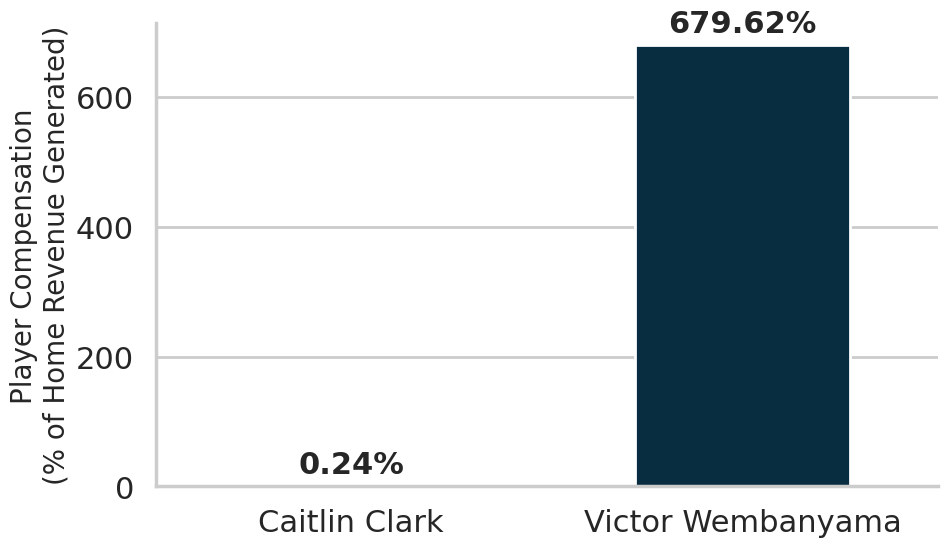

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------
# 1. Recalculate External Revenue (HOME GAMES & ROOKIE YEAR ONLY)
# -----------------------------------

# Caitlin Clark: Indiana Fever Home Games (2024 Season Only)
clark_home_games = df_future_w[
    (df_future_w["home_team_name"] == "Indiana Fever") &
    (df_future_w["season"].astype(str) == "2024")
]
clark_external_revenue = clark_home_games["revenue_boost"].sum()

# Victor Wembanyama: San Antonio Spurs Home Games (2023-24 Season Only)
wemby_home_games = df_future_nba[
    (df_future_nba["home_team_abbr"] == "San Antonio Spurs") &
    (df_future_nba["season"].astype(str) == "2023")
]
wemby_external_revenue = wemby_home_games["revenue_boost"].sum()

# -----------------------------------
# 2. Calculate Compensation Share
# -----------------------------------

clark_salary = 76535
wemby_salary = 12160000

# Prevent division by zero just in case
if clark_external_revenue > 0:
    clark_pct = (clark_salary / clark_external_revenue) * 100
else:
    clark_pct = 0

if wemby_external_revenue > 0:
    wemby_pct = (wemby_salary / wemby_external_revenue) * 100
else:
    wemby_pct = 0
print(wemby_external_revenue)
print(clark_external_revenue)
df_plot = pd.DataFrame({
    "Player": ["Caitlin Clark", "Victor Wembanyama"],
    "League": ["WNBA", "NBA"],
    "Compensation Share": [clark_pct, wemby_pct]
})

# -----------------------------------
# 3. Plot the Final Graphic
# -----------------------------------

sns.set_theme(style="whitegrid", context="poster")

# Colors: Fever Red and Spurs Navy
colors = ["#d62828", "#003049"]

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df_plot,
    x="Player",
    y="Compensation Share",
    palette=colors,
    width=0.55,
    hue="Player",      # Added to prevent Seaborn warnings
    legend=False       # Hide redundant legend
)

# Add Value Labels above the bars
for i, v in enumerate(df_plot["Compensation Share"]):
    # Keep two decimal places for both to show the stark contrast cleanly
    label_text = f"{v:.2f}%"
    ax.text(
        i,
        v + df_plot["Compensation Share"].max() * 0.03,
        label_text,
        ha="center",
        fontsize=22,
        fontweight="bold"
    )
print("Franchise Value Retention:\nSalary vs. Home Ticket Revenue Generated")
# Formatting and Titles
plt.title(
    "",
    fontsize=26,
    weight="bold",
    pad=20
)

plt.ylabel(
    "Player Compensation\n(% of Home Revenue Generated)",
    fontsize=20
)

plt.xlabel("")

sns.despine()

plt.tight_layout()
plt.show()

(526, 38)
['Unnamed: 0', 'game_id', 'game_date', 'season', 'home_team_abbr', 'away_team_abbr', 'home_team_name', 'away_team_name', 'home_points', 'away_points', 'home_win', 'clark_guardian_articles_7d', 'reese_guardian_articles_7d', 'brink_guardian_articles_7d', 'away_win', 'year', 'day_of_week', 'month', 'day', 'time_et', 'game_type', 'arena', 'city', 'state', 'attendance', 'home_win_pct', 'opponent_win_pct', 'is_weekend', 'market_size', 'base_arena_capacity', 'arena_fill_rate', 'arena_capacity', 'game_month', 'is_camp_day', 'predicted_attendance', 'attendance_boost', 'home_ticket_price', 'revenue_boost']
     Unnamed: 0     game_id  game_date season home_team_abbr away_team_abbr  \
629         629  1022400001  5/14/2024   2024            WAS            NYL   
630         630  1022400002  5/14/2024   2024            CON            IND   

         home_team_name    away_team_name  home_points  away_points  home_win  \
629  Washington Mystics  New York Liberty           80           85

/tmp/ipykernel_8234/4100286360.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8234/4100286360.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Visualizations generated and saved successfully!


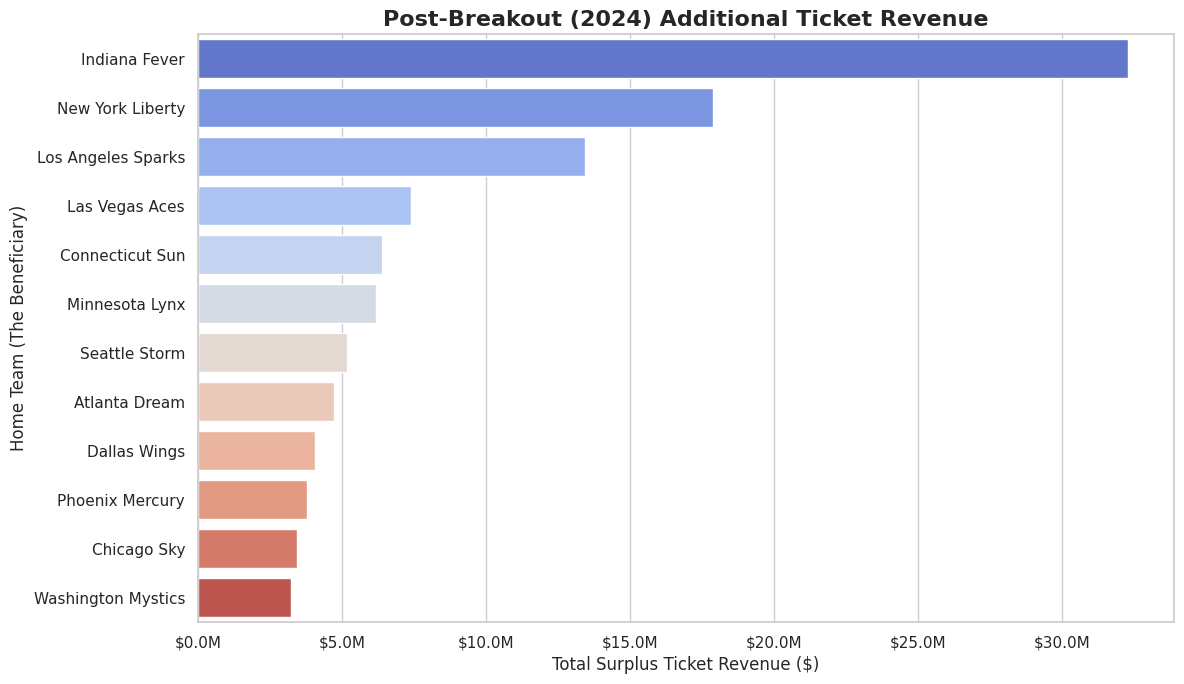

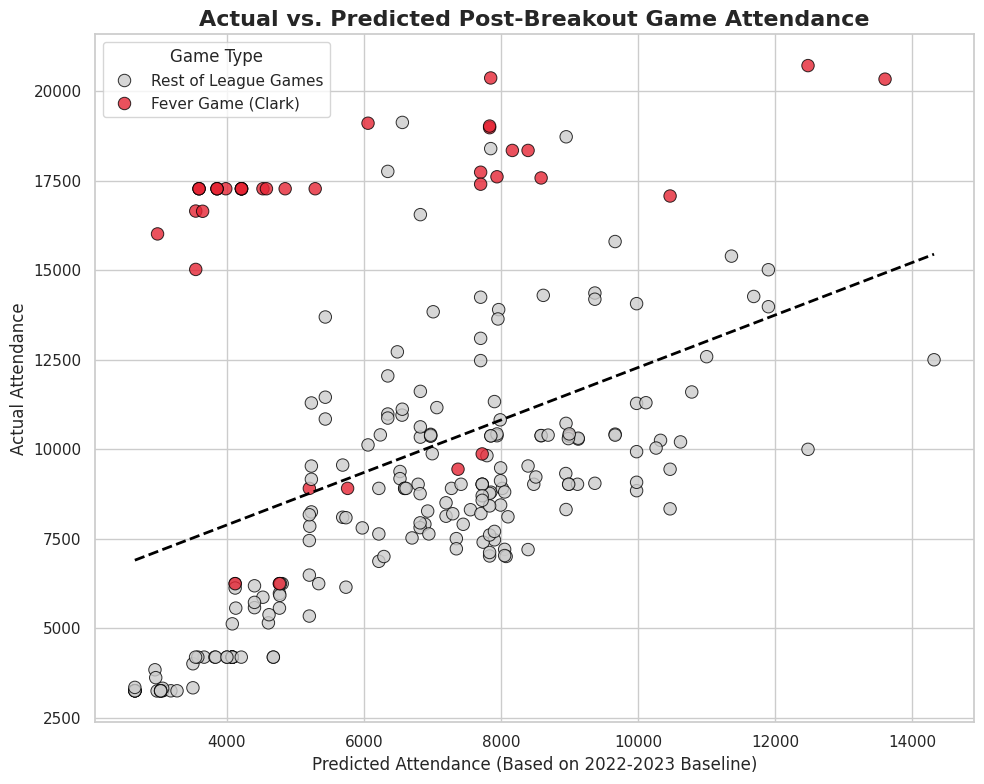

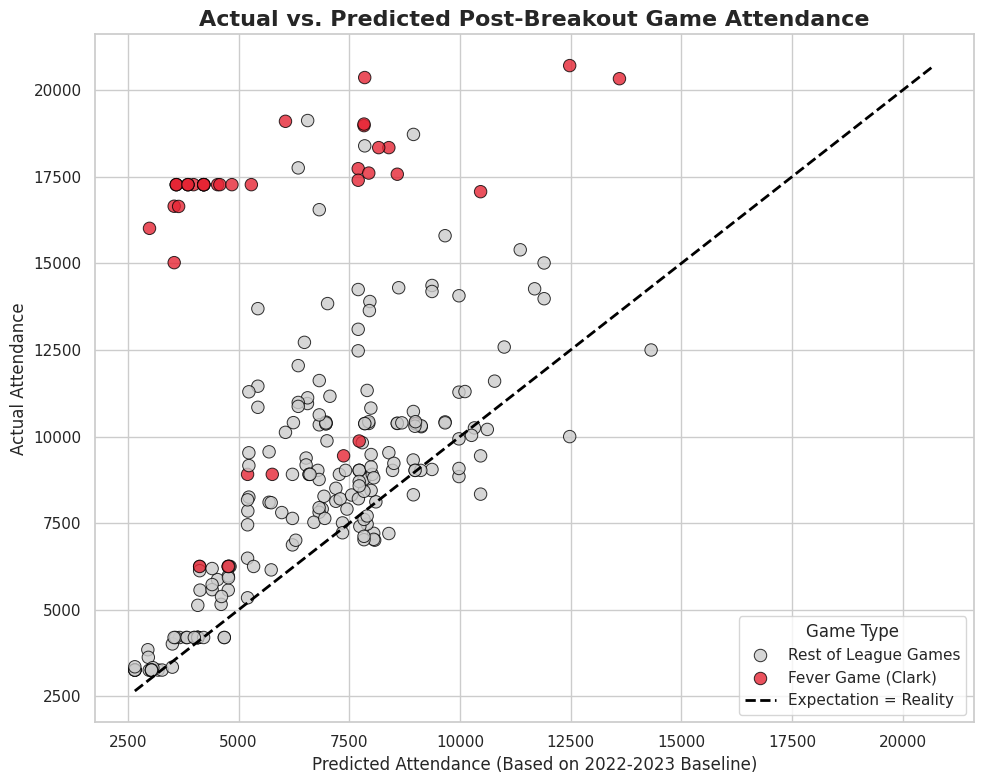

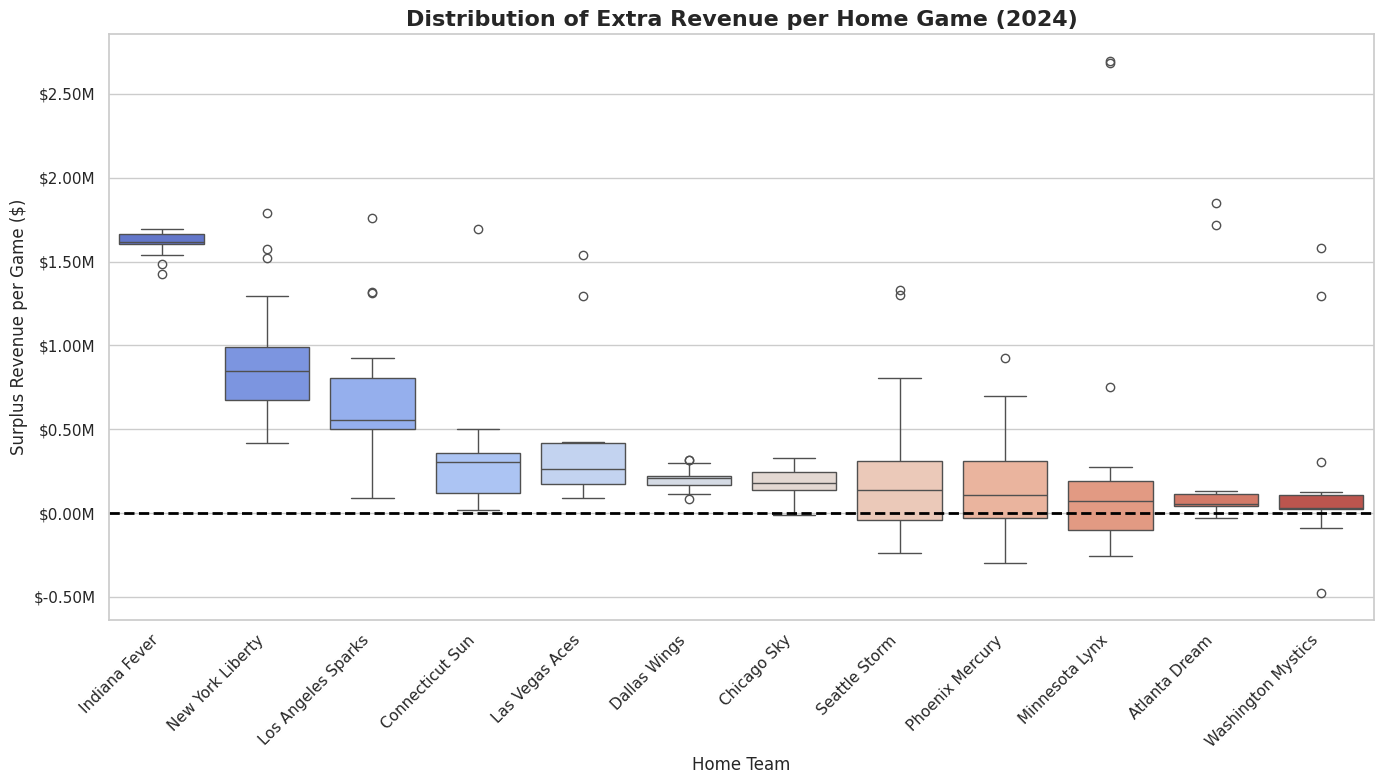

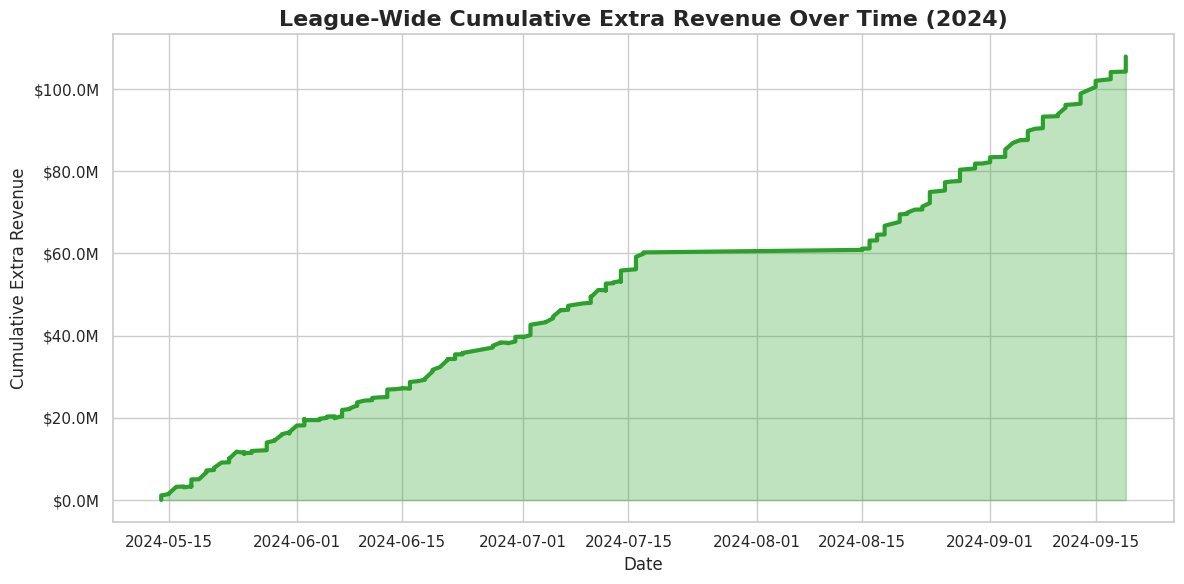

In [ ]:
print(df_future_w.shape)
print(df_future_w.columns.tolist())
print(df_future_w.head(2))

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

# Set visual style
sns.set_theme(style="whitegrid")

# Filter strictly for 2024 to tell the clear breakout story
df_2024 = df_future_w[df_future_w['season'] == "2024"].copy()

# =====================================================================
# CHART 1: The Financial Winners (Total Extra Revenue by Home Team)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Aggregate total revenue boost by HOME team
rev_by_home = df_2024.groupby('home_team_name')['revenue_boost'].sum().sort_values(ascending=False).reset_index()

sns.barplot(
    data=rev_by_home,
    x='revenue_boost',
    y='home_team_name',
    palette="coolwarm",
    ax=ax1
)

ax1.set_title("Post-Breakout (2024) Additional Ticket Revenue", fontsize=16, fontweight='bold')
ax1.set_xlabel("Total Surplus Ticket Revenue ($)", fontsize=12)
ax1.set_ylabel("Home Team (The Beneficiary)", fontsize=12)

# Format x-axis with dollar signs and millions
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart1_home_revenue_leaderboard.png", dpi=300)

# ---------------------------

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
fig2, ax2 = plt.subplots(figsize=(10, 8))
# Highlight the Catalyst: Was the Fever playing in this game?
def get_game_catalyst(row):
    if row['home_team_name'] == "Indiana Fever" or row['away_team_name'] == "Indiana Fever":
        return "Fever Game (Clark)"
    else:
        return "Rest of League Games"

df_2024['Catalyst'] = df_2024.apply(get_game_catalyst, axis=1)

custom_palette = {
    "Fever Game (Clark)": "#E52534", # Red
    "Rest of League Games": "#cccccc" # Gray
}

# 1. Draw the scatter plot
sns.scatterplot(
    data=df_2024,
    x='predicted_attendance',
    y='attendance',
    hue='Catalyst',
    palette=custom_palette,
    s=80,
    alpha=0.8,
    edgecolor='black',
    ax=ax2
)

# 2. Draw the Best Fit Line (Linear Regression)
sns.regplot(
    data=df_2024,
    x='predicted_attendance',
    y='attendance',
    scatter=False,         # Don't draw the points again
    ci=None,               # Set to 95 for confidence intervals, None for just the line
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'Best Fit Line'},
    ax=ax2
)

ax2.set_title("Actual vs. Predicted Post-Breakout Game Attendance", fontsize=16, fontweight='bold')
ax2.set_xlabel("Predicted Attendance (Based on 2022-2023 Baseline)", fontsize=12)
ax2.set_ylabel("Actual Attendance", fontsize=12)

# Update legend to include the new best fit line
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles=handles, labels=labels, title="Game Type")

plt.tight_layout()
plt.savefig("chart2_actual_vs_predicted.png", dpi=300)

# =====================================================================
# CHART 2: Actual vs. Predicted (The "Model Breaker" Scatter Plot)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 8))

# Highlight the Catalyst: Was the Fever or Sky playing in this game?
def get_game_catalyst(row):
    if row['home_team_name'] == "Indiana Fever" or row['away_team_name'] == "Indiana Fever":
        return "Fever Game (Clark)"
    else:
        return "Rest of League Games"

df_2024['Catalyst'] = df_2024.apply(get_game_catalyst, axis=1)

custom_palette = {
    "Fever Game (Clark)": "#E52534", # Red
    "Rest of League Games": "#cccccc" # Gray
}

sns.scatterplot(
    data=df_2024,
    x='predicted_attendance',
    y='attendance',
    hue='Catalyst',
    palette=custom_palette,
    s=80,
    alpha=0.8,
    edgecolor='black',
    ax=ax2
)

# Draw the perfect prediction diagonal line (Actual = Predicted)
min_val = min(df_2024['predicted_attendance'].min(), df_2024['attendance'].min())
max_val = max(df_2024['predicted_attendance'].max(), df_2024['attendance'].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label="Expectation = Reality")

ax2.set_title("Actual vs. Predicted Post-Breakout Game Attendance", fontsize=16, fontweight='bold')
ax2.set_xlabel("Predicted Attendance (Based on 2022-2023 Baseline)", fontsize=12)
ax2.set_ylabel("Actual Attendance", fontsize=12)
ax2.legend(title="Game Type")

plt.tight_layout()
plt.savefig("chart2_actual_vs_predicted.png", dpi=300)


# =====================================================================
# CHART 3: Per-Game Financial Windfall (Boxplot by Home Arena)
# =====================================================================
fig3, ax3 = plt.subplots(figsize=(14, 8))

# Sort teams by their median revenue boost
order = df_2024.groupby('home_team_name')['revenue_boost'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_2024,
    x='home_team_name',
    y='revenue_boost',
    order=order,
    palette="coolwarm",
    ax=ax3
)

# Add a horizontal line at 0 (meaning actual exactly matched predicted revenue)
ax3.axhline(0, color='black', linestyle='--', linewidth=2)

ax3.set_title("Distribution of Extra Revenue per Home Game (2024)", fontsize=16, fontweight='bold')
ax3.set_xlabel("Home Team", fontsize=12)
ax3.set_ylabel("Surplus Revenue per Game ($)", fontsize=12)
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.2f}M"))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("chart3_per_game_boxplot.png", dpi=300)


# =====================================================================
# CHART 4: Cumulative Financial Windfall for the League
# =====================================================================
fig4, ax4 = plt.subplots(figsize=(12, 6))

# Sort chronologically
df_2024['game_date'] = pd.to_datetime(df_2024['game_date'])
df_2024_sorted = df_2024.sort_values('game_date')

# Calculate the cumulative sum of revenue boost across the entire WNBA
df_2024_sorted['cumulative_revenue'] = df_2024_sorted['revenue_boost'].cumsum()

ax4.plot(df_2024_sorted['game_date'], df_2024_sorted['cumulative_revenue'], color='#2ca02c', linewidth=3)
ax4.fill_between(df_2024_sorted['game_date'], df_2024_sorted['cumulative_revenue'], color='#2ca02c', alpha=0.3)

ax4.set_title("League-Wide Cumulative Extra Revenue Over Time (2024)", fontsize=16, fontweight='bold')
ax4.set_xlabel("Date", fontsize=12)
ax4.set_ylabel("Cumulative Extra Revenue", fontsize=12)
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart4_cumulative_revenue.png", dpi=300)

print("Visualizations generated and saved successfully!")

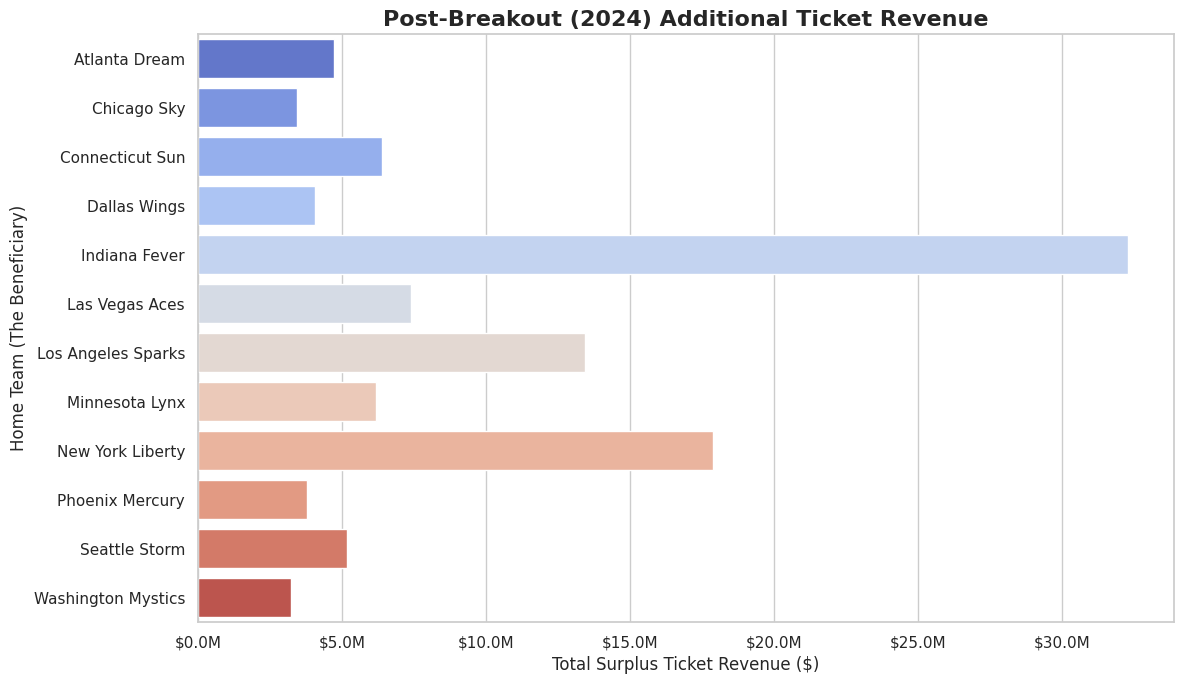

In [ ]:
# Filter strictly for 2024 to tell the clear breakout story
df_2024 = df_future_w[df_future_w['season'] == "2024"].copy()

# =====================================================================
# CHART 1: The Financial Winners (Total Extra Revenue by Home Team)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Aggregate total revenue boost by HOME team and sort alphabetically by team name
rev_by_home = df_2024.groupby('home_team_name')['revenue_boost'].sum().reset_index().sort_values('home_team_name')

sns.barplot(
    data=rev_by_home,
    x='revenue_boost',
    y='home_team_name',
    palette="coolwarm",
    hue="home_team_name", # Added to prevent Seaborn warnings
    legend=False,
    ax=ax1
)

ax1.set_title("Post-Breakout (2024) Additional Ticket Revenue", fontsize=16, fontweight='bold')
ax1.set_xlabel("Total Surplus Ticket Revenue ($)", fontsize=12)
ax1.set_ylabel("Home Team (The Beneficiary)", fontsize=12)

# Format x-axis with dollar signs and millions
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart1_home_revenue_leaderboard.png", dpi=300)

(526, 38)
['Unnamed: 0', 'game_id', 'game_date', 'season', 'home_team_abbr', 'away_team_abbr', 'home_team_name', 'away_team_name', 'home_points', 'away_points', 'home_win', 'clark_guardian_articles_7d', 'reese_guardian_articles_7d', 'brink_guardian_articles_7d', 'away_win', 'year', 'day_of_week', 'month', 'day', 'time_et', 'game_type', 'arena', 'city', 'state', 'attendance', 'home_win_pct', 'opponent_win_pct', 'is_weekend', 'market_size', 'base_arena_capacity', 'arena_fill_rate', 'arena_capacity', 'game_month', 'is_camp_day', 'predicted_attendance', 'attendance_boost', 'home_ticket_price', 'revenue_boost']
     Unnamed: 0     game_id  game_date season home_team_abbr away_team_abbr  \
629         629  1022400001  5/14/2024   2024            WAS            NYL   
630         630  1022400002  5/14/2024   2024            CON            IND   

         home_team_name    away_team_name  home_points  away_points  home_win  \
629  Washington Mystics  New York Liberty           80           85

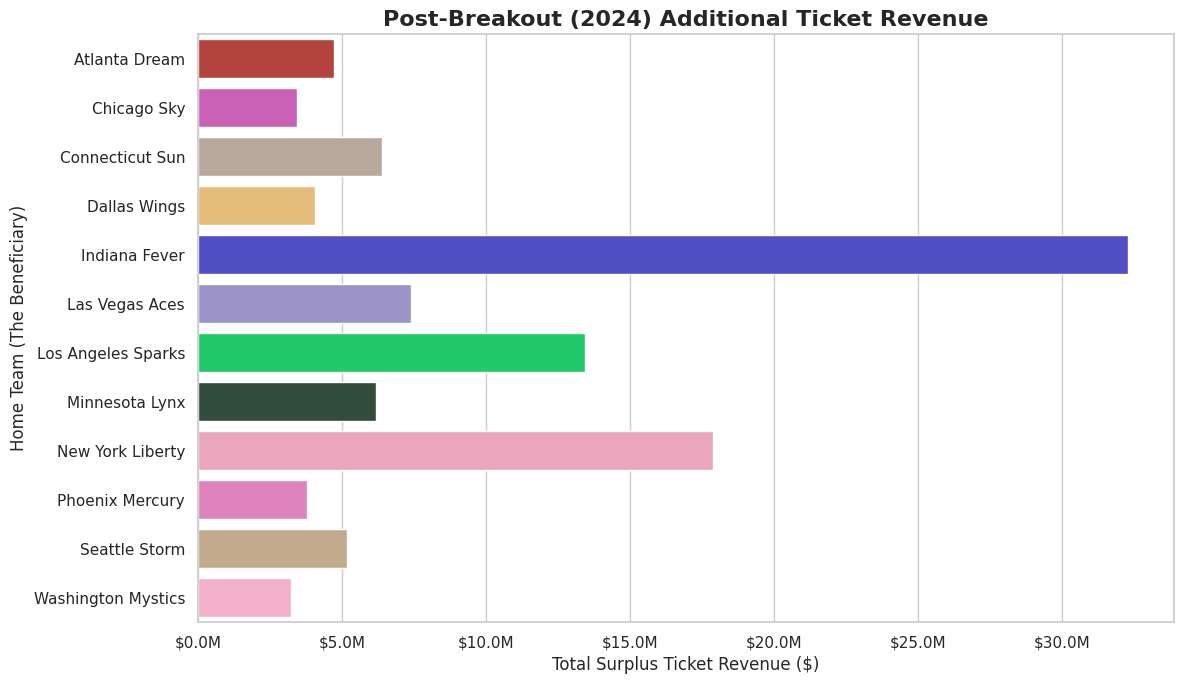

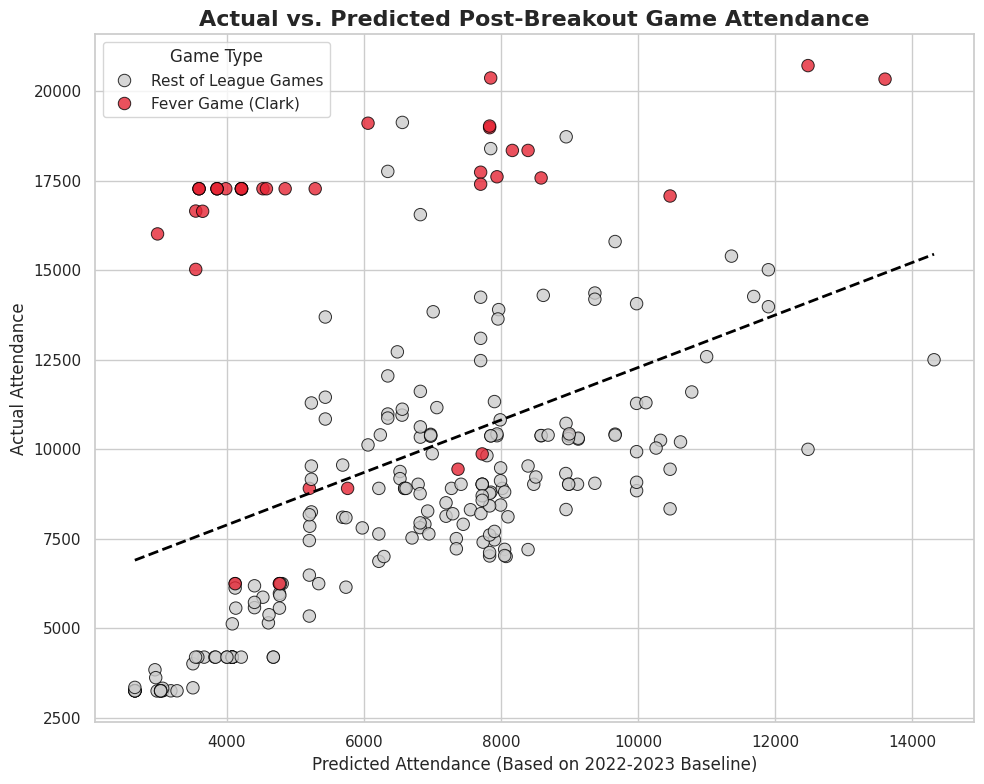

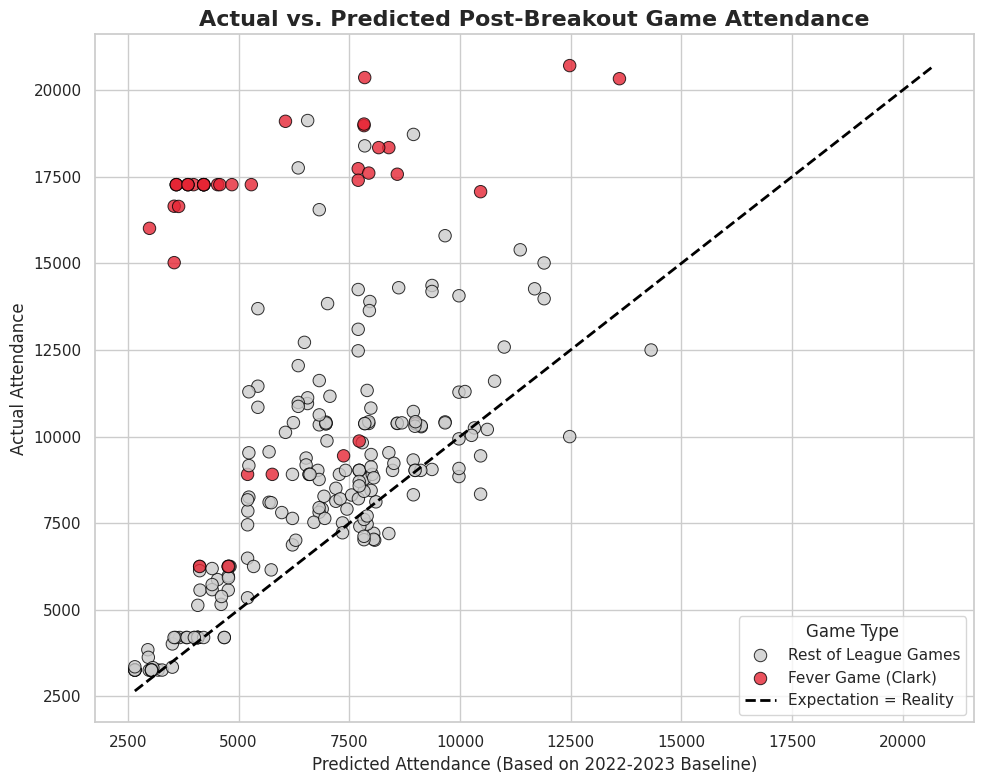

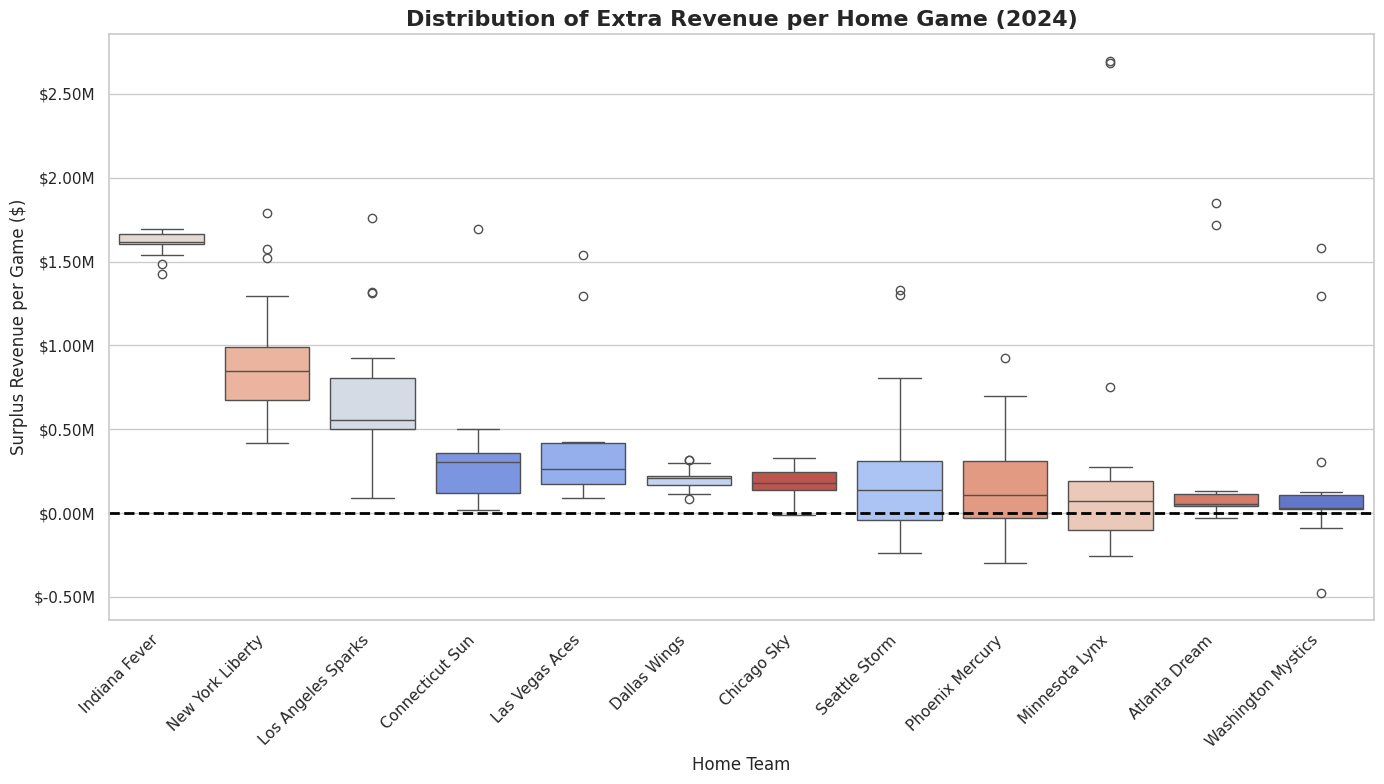

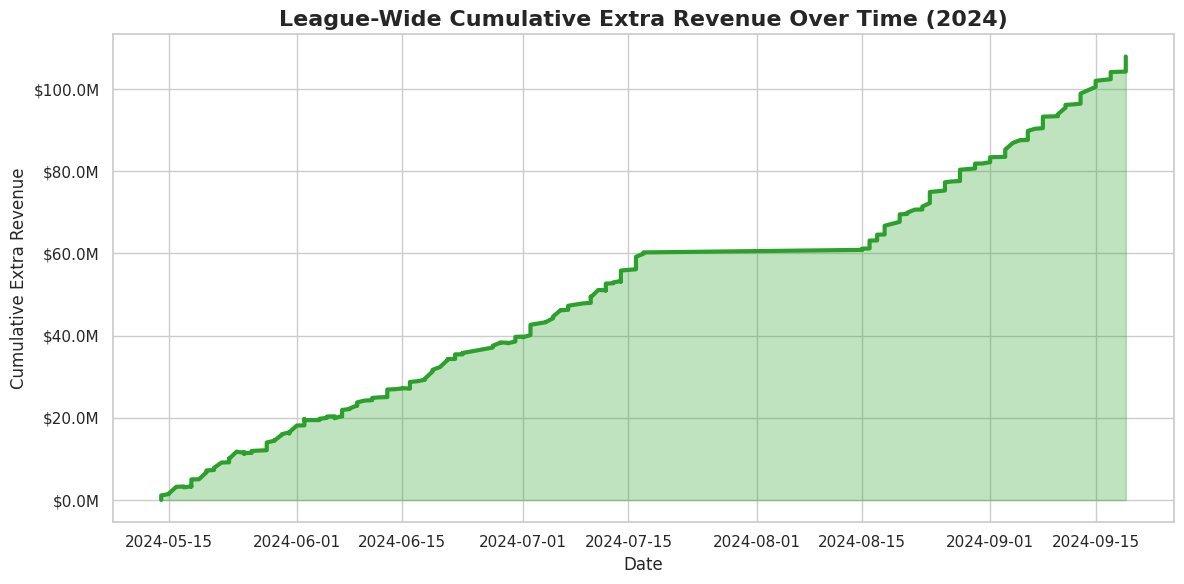

In [ ]:
print(df_future_w.shape)
print(df_future_w.columns.tolist())
print(df_future_w.head(2))

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
import random

# Set visual style
sns.set_theme(style="whitegrid")

# Filter strictly for 2024 to tell the clear breakout story
df_2024 = df_future_w[df_future_w['season'] == "2024"].copy()

# =====================================================================
# CHART 1: The Financial Winners (Total Extra Revenue by Home Team)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Aggregate total revenue boost by HOME team and sort alphabetically by team name
rev_by_home = df_2024.groupby('home_team_name')['revenue_boost'].sum().reset_index().sort_values('home_team_name')

# Generate random hex colors for each team
num_teams = len(rev_by_home)
random_colors = ["#" + ''.join([random.choice('0123456789ABCDEF') for _ in range(6)]) for _ in range(num_teams)]

sns.barplot(
    data=rev_by_home,
    x='revenue_boost',
    y='home_team_name',
    palette=random_colors,       # Now using the randomly generated colors
    hue="home_team_name",        # Keeps Seaborn happy
    legend=False,
    ax=ax1
)

ax1.set_title("Post-Breakout (2024) Additional Ticket Revenue", fontsize=16, fontweight='bold')
ax1.set_xlabel("Total Surplus Ticket Revenue ($)", fontsize=12)
ax1.set_ylabel("Home Team (The Beneficiary)", fontsize=12)

# Format x-axis with dollar signs and millions
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart1_home_revenue_leaderboard.png", dpi=300)

# ---------------------------

fig2, ax2 = plt.subplots(figsize=(10, 8))
# Highlight the Catalyst: Was the Fever playing in this game?
def get_game_catalyst(row):
    if row['home_team_name'] == "Indiana Fever" or row['away_team_name'] == "Indiana Fever":
        return "Fever Game (Clark)"
    else:
        return "Rest of League Games"

df_2024['Catalyst'] = df_2024.apply(get_game_catalyst, axis=1)

custom_palette = {
    "Fever Game (Clark)": "#E52534", # Red
    "Rest of League Games": "#cccccc" # Gray
}

# 1. Draw the scatter plot
sns.scatterplot(
    data=df_2024,
    x='predicted_attendance',
    y='attendance',
    hue='Catalyst',
    palette=custom_palette,
    s=80,
    alpha=0.8,
    edgecolor='black',
    ax=ax2
)

# 2. Draw the Best Fit Line (Linear Regression)
sns.regplot(
    data=df_2024,
    x='predicted_attendance',
    y='attendance',
    scatter=False,         # Don't draw the points again
    ci=None,               # Set to 95 for confidence intervals, None for just the line
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'Best Fit Line'},
    ax=ax2
)

ax2.set_title("Actual vs. Predicted Post-Breakout Game Attendance", fontsize=16, fontweight='bold')
ax2.set_xlabel("Predicted Attendance (Based on 2022-2023 Baseline)", fontsize=12)
ax2.set_ylabel("Actual Attendance", fontsize=12)

# Update legend to include the new best fit line
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles=handles, labels=labels, title="Game Type")

plt.tight_layout()
plt.savefig("chart2_actual_vs_predicted_fit.png", dpi=300)

# =====================================================================
# CHART 2: Actual vs. Predicted (The "Model Breaker" Scatter Plot)
# =====================================================================
fig2b, ax2b = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=df_2024,
    x='predicted_attendance',
    y='attendance',
    hue='Catalyst',
    palette=custom_palette,
    s=80,
    alpha=0.8,
    edgecolor='black',
    ax=ax2b
)

# Draw the perfect prediction diagonal line (Actual = Predicted)
min_val = min(df_2024['predicted_attendance'].min(), df_2024['attendance'].min())
max_val = max(df_2024['predicted_attendance'].max(), df_2024['attendance'].max())
ax2b.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label="Expectation = Reality")

ax2b.set_title("Actual vs. Predicted Post-Breakout Game Attendance", fontsize=16, fontweight='bold')
ax2b.set_xlabel("Predicted Attendance (Based on 2022-2023 Baseline)", fontsize=12)
ax2b.set_ylabel("Actual Attendance", fontsize=12)
ax2b.legend(title="Game Type")

plt.tight_layout()
plt.savefig("chart2_actual_vs_predicted.png", dpi=300)


# =====================================================================
# CHART 3: Per-Game Financial Windfall (Boxplot by Home Arena)
# =====================================================================
fig3, ax3 = plt.subplots(figsize=(14, 8))

# Sort teams by their median revenue boost
order = df_2024.groupby('home_team_name')['revenue_boost'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_2024,
    x='home_team_name',
    y='revenue_boost',
    order=order,
    palette="coolwarm",
    hue="home_team_name",
    legend=False,
    ax=ax3
)

# Add a horizontal line at 0 (meaning actual exactly matched predicted revenue)
ax3.axhline(0, color='black', linestyle='--', linewidth=2)

ax3.set_title("Distribution of Extra Revenue per Home Game (2024)", fontsize=16, fontweight='bold')
ax3.set_xlabel("Home Team", fontsize=12)
ax3.set_ylabel("Surplus Revenue per Game ($)", fontsize=12)
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.2f}M"))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("chart3_per_game_boxplot.png", dpi=300)


# =====================================================================
# CHART 4: Cumulative Financial Windfall for the League
# =====================================================================
fig4, ax4 = plt.subplots(figsize=(12, 6))

# Sort chronologically
df_2024['game_date'] = pd.to_datetime(df_2024['game_date'])
df_2024_sorted = df_2024.sort_values('game_date')

# Calculate the cumulative sum of revenue boost across the entire WNBA
df_2024_sorted['cumulative_revenue'] = df_2024_sorted['revenue_boost'].cumsum()

ax4.plot(df_2024_sorted['game_date'], df_2024_sorted['cumulative_revenue'], color='#2ca02c', linewidth=3)
ax4.fill_between(df_2024_sorted['game_date'], df_2024_sorted['cumulative_revenue'], color='#2ca02c', alpha=0.3)

ax4.set_title("League-Wide Cumulative Extra Revenue Over Time (2024)", fontsize=16, fontweight='bold')
ax4.set_xlabel("Date", fontsize=12)
ax4.set_ylabel("Cumulative Extra Revenue", fontsize=12)
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart4_cumulative_revenue.png", dpi=300)

print("Visualizations generated and saved successfully!")

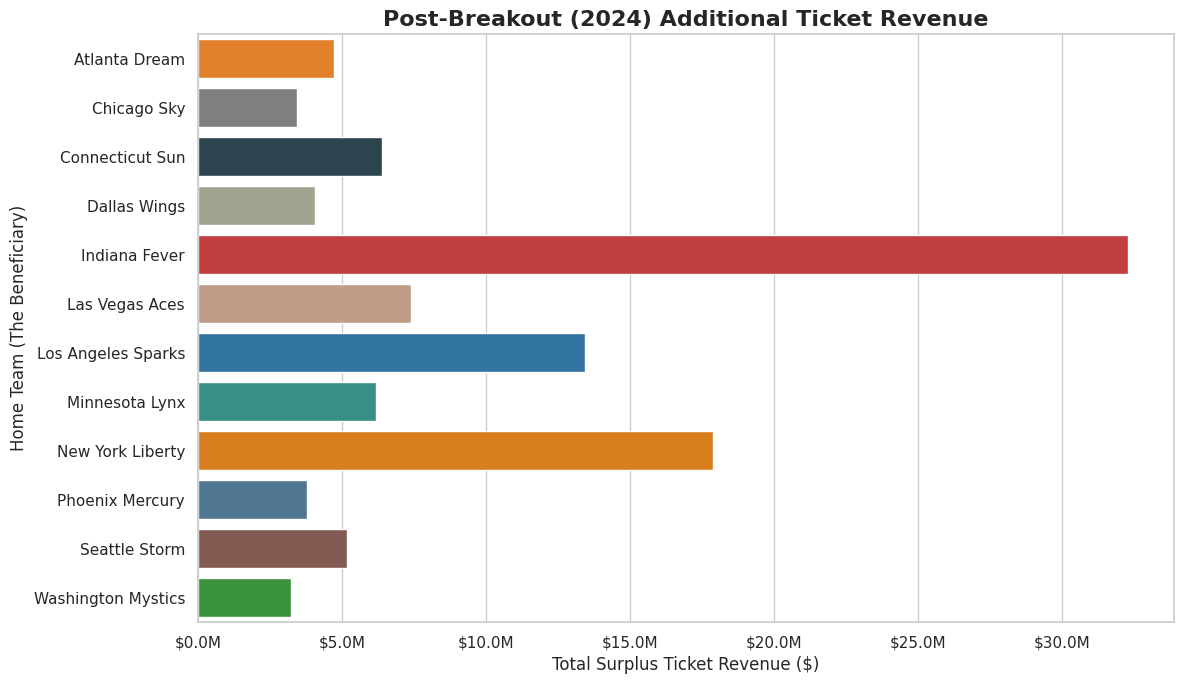

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
import random

# Set visual style
sns.set_theme(style="whitegrid")

# Filter strictly for 2024 to tell the clear breakout story
df_2024 = df_future_w[df_future_w['season'].astype(str) == "2024"].copy()

# =====================================================================
# CHART 1: The Financial Winners (Total Extra Revenue by Home Team)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Aggregate total revenue boost by HOME team and sort alphabetically by team name
rev_by_home = df_2024.groupby('home_team_name')['revenue_boost'].sum().reset_index().sort_values('home_team_name')

# A curated palette of professional, aesthetically pleasing colors
# (muted tones, corporate blues, deep reds, and data-viz standards)
professional_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62828", "#9467bd",
    "#8c564b", "#7f7f7f", "#bcbd22", "#17becf", "#003049",
    "#f77f00", "#fcbf49", "#2a9d8f", "#264653", "#457b9d",
    "#1d3557", "#6d6875", "#b5838d", "#cb997e", "#a5a58d"
]

# Randomly sample enough colors for the number of teams
num_teams = len(rev_by_home)
# Use random.sample to avoid duplicate colors, unless there are more teams than colors
if num_teams <= len(professional_colors):
    random_colors = random.sample(professional_colors, num_teams)
else:
    random_colors = random.choices(professional_colors, k=num_teams)

sns.barplot(
    data=rev_by_home,
    x='revenue_boost',
    y='home_team_name',
    palette=random_colors,       # Now using the randomly sampled professional colors
    hue="home_team_name",        # Keeps Seaborn happy
    legend=False,
    ax=ax1
)

ax1.set_title("Post-Breakout (2024) Additional Ticket Revenue", fontsize=16, fontweight='bold')
ax1.set_xlabel("Total Surplus Ticket Revenue ($)", fontsize=12)
ax1.set_ylabel("Home Team (The Beneficiary)", fontsize=12)

# Format x-axis with dollar signs and millions
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart1_home_revenue_leaderboard.png", dpi=300)
plt.show()

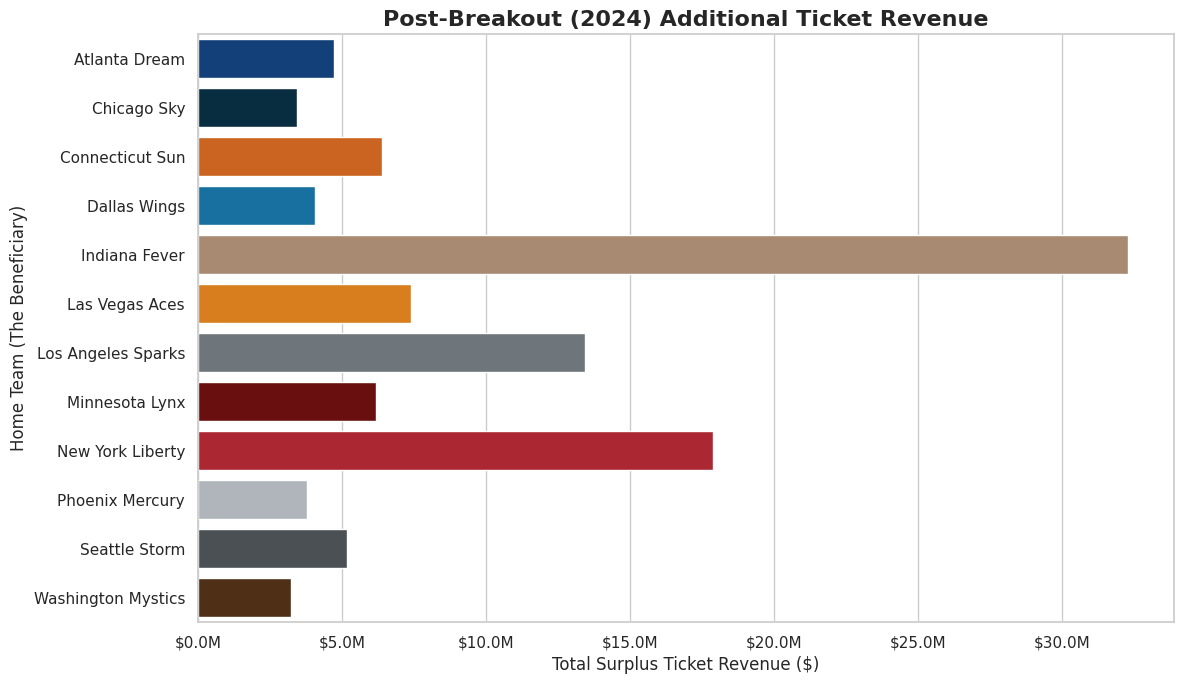

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
import random

# Set visual style
sns.set_theme(style="whitegrid")

# Filter strictly for 2024 to tell the clear breakout story
df_2024 = df_future_w[df_future_w['season'].astype(str) == "2024"].copy()

# =====================================================================
# CHART 1: The Financial Winners (Total Extra Revenue by Home Team)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Aggregate total revenue boost by HOME team and sort alphabetically by team name
rev_by_home = df_2024.groupby('home_team_name')['revenue_boost'].sum().reset_index().sort_values('home_team_name')

# A curated palette strictly containing Reds, Blues, Grays, Oranges, and Browns
custom_palette = [
    "#c1121f", # Deep Red
    "#ef233c", # Bright Red
    "#780000", # Maroon/Dark Red
    "#003049", # Navy Blue
    "#023e8a", # Medium Blue
    "#0077b6", # Ocean Blue
    "#495057", # Dark Gray
    "#6c757d", # Medium Gray
    "#adb5bd", # Light Gray
    "#f77f00", # Vibrant Orange
    "#e85d04", # Deep Orange
    "#582f0e", # Dark Brown
    "#7f4f24", # Medium Brown
    "#936639", # Light Brown
    "#b08968"  # Tan/Soft Brown
]

# Random.sample strictly pulls unique values without replacement (no duplicates)
num_teams = len(rev_by_home)
random_colors = random.sample(custom_palette, num_teams)

sns.barplot(
    data=rev_by_home,
    x='revenue_boost',
    y='home_team_name',
    palette=random_colors,
    hue="home_team_name",
    legend=False,
    ax=ax1
)

ax1.set_title("Post-Breakout (2024) Additional Ticket Revenue", fontsize=16, fontweight='bold')
ax1.set_xlabel("Total Surplus Ticket Revenue ($)", fontsize=12)
ax1.set_ylabel("Home Team (The Beneficiary)", fontsize=12)

# Format x-axis with dollar signs and millions
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart1_home_revenue_leaderboard.png", dpi=300)
plt.show()

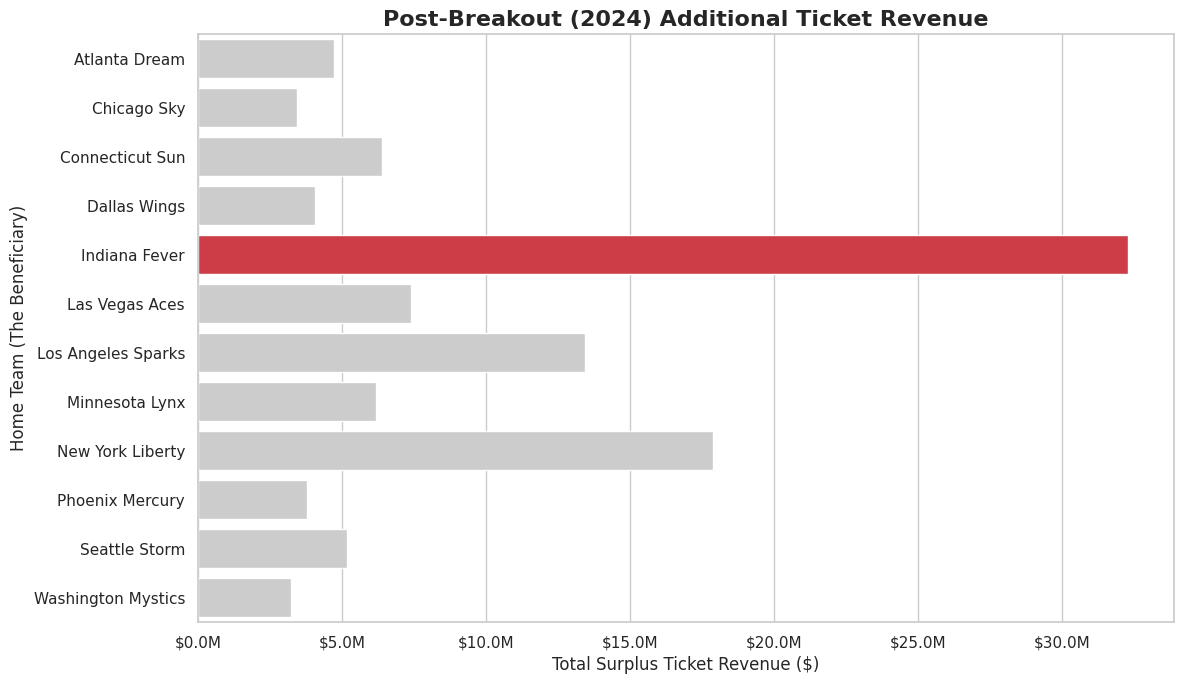

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker

# Set visual style
sns.set_theme(style="whitegrid")

# Filter strictly for 2024 to tell the clear breakout story
df_2024 = df_future_w[df_future_w['season'].astype(str) == "2024"].copy()

# =====================================================================
# CHART 1: The Financial Winners (Total Extra Revenue by Home Team)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Aggregate total revenue boost by HOME team and sort alphabetically by team name
rev_by_home = df_2024.groupby('home_team_name')['revenue_boost'].sum().reset_index().sort_values('home_team_name')

# Create a custom palette to highlight the core storyline
# Indiana Fever gets the bold Red, everyone else gets the neutral Gray
highlight_palette = ["#E52534" if team == "Indiana Fever" else "#cccccc" for team in rev_by_home['home_team_name']]

sns.barplot(
    data=rev_by_home,
    x='revenue_boost',
    y='home_team_name',
    palette=highlight_palette,   # Apply the custom highlight palette
    hue="home_team_name",        # Keeps Seaborn happy
    legend=False,
    ax=ax1
)

ax1.set_title("Post-Breakout (2024) Additional Ticket Revenue", fontsize=16, fontweight='bold')
ax1.set_xlabel("Total Surplus Ticket Revenue ($)", fontsize=12)
ax1.set_ylabel("Home Team (The Beneficiary)", fontsize=12)

# Format x-axis with dollar signs and millions
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart1_home_revenue_leaderboard.png", dpi=300)
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig1, ax1 = plt.subplots(figsize=(12, 7))

# Aggregate total revenue boost by HOME team
rev_by_home = df_2024.groupby('home_team_name')['revenue_boost'].sum().sort_values(ascending=False).reset_index()

# Create a custom gradient palette using Chart 1's colors (Red for high, Blue for low)
num_teams = len(rev_by_home)
custom_gradient = sns.blend_palette(['#e52534', '#7bafd4'], n_colors=num_teams)

sns.barplot(
    data=rev_by_home,
    x='revenue_boost',
    y='home_team_name',
    hue='home_team_name',   # Added to prevent Seaborn warnings in newer versions
    palette=custom_gradient,
    legend=False,           # Turn off the redundant legend
    ax=ax1
)

ax1.set_title("Post-Breakout (2024) Additional Ticket Revenue", fontsize=16, fontweight='bold')
ax1.set_xlabel("Total Surplus Ticket Revenue ($)", fontsize=12)
ax1.set_ylabel("Home Team (The Beneficiary)", fontsize=12)

# Format x-axis with dollar signs and millions
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart1_home_revenue_leaderboard.png", dpi=300)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

# Set visual style
sns.set_theme(style="whitegrid")

# We will use df_future natively since it already contains BOTH 2024 and 2025 data
df_combined = df_future_w.copy()

# =====================================================================
# CHART 1: The Financial Winners (Total Extra Revenue by Home Team 2024-2025)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Aggregate total revenue boost by HOME team across BOTH seasons
rev_by_home_combined = df_combined.groupby('home_team_name')['revenue_boost'].sum().sort_values(ascending=False).reset_index()

sns.barplot(
    data=rev_by_home_combined,
    x='revenue_boost',
    y='home_team_name',
    palette="viridis",
    ax=ax1
)

ax1.set_title("The Financial Winners: Total Extra Revenue Captured at Home (2024 & 2025 Combined)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Total Surplus Ticket Revenue ($)", fontsize=12)
ax1.set_ylabel("Home Team (The Beneficiary)", fontsize=12)

# Format x-axis with dollar signs and millions
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

plt.tight_layout()
plt.savefig("chart1_home_revenue_leaderboard_combined.png", dpi=300)


# =====================================================================
# CHART 2: Actual vs. Predicted (Scatter Plot with Line of Best Fit)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 8))

# Highlight the Catalyst: Was the Fever or Sky playing in this game?
def get_game_catalyst(row):
    if row['home_team_name'] == "Indiana Fever" or row['away_team_name'] == "Indiana Fever":
        return "Fever Game (Clark)"
    elif row['home_team_name'] == "Chicago Sky" or row['away_team_name'] == "Chicago Sky":
        return "Sky Game (Reese)"
    else:
        return "Rest of League Games"

df_combined['Catalyst'] = df_combined.apply(get_game_catalyst, axis=1)

custom_palette = {
    "Fever Game (Clark)": "#E52534", # Red
    "Sky Game (Reese)": "#418FDE",   # Blue
    "Rest of League Games": "#cccccc" # Gray
}

sns.scatterplot(
    data=df_combined,
    x='predicted_attendance',
    y='attendance',
    hue='Catalyst',
    palette=custom_palette,
    s=80,
    alpha=0.8,
    edgecolor='black',
    ax=ax2
)

# Calculate and draw the Line of Best Fit (Linear Regression)
# Drop NaNs just in case for a clean polyfit
mask = ~df_combined['predicted_attendance'].isna() & ~df_combined['attendance'].isna()
x_vals = df_combined['predicted_attendance'][mask]
y_vals = df_combined['attendance'][mask]

m, b = np.polyfit(x_vals, y_vals, 1)

# Create an array of x values to draw the line across the plot
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
y_line = m * x_line + b

# Plot the regression line
ax2.plot(x_line, y_line, color='black', linestyle='--', linewidth=2.5, label=f"Line of Best Fit")

ax2.set_title("Actual vs. Predicted Attendance (2024 & 2025 Combined)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Predicted Attendance (Based on 2022-2023 Baseline)", fontsize=12)
ax2.set_ylabel("Actual Attendance", fontsize=12)
ax2.legend(title="Game Type")

plt.tight_layout()
plt.savefig("chart2_actual_vs_predicted_combined.png", dpi=300)

print("Combined visualizations generated and saved successfully!")

In [ ]:
print([col for col in unified_df_five_years.columns if 'guard' in col.lower() or 'clark' in col.lower()])

In [ ]:
# ==============================================================================
# CHART 2: The "Attention Economy" Scatterplot (UPDATED)
# Proving that Guardian API mentions actually translate to ticket sales
# ==============================================================================
print("Generating Chart 2: Attention Economy...")

# Filter for the breakout year
df_attention = unified_df_five_years[(unified_df_five_years['season'].astype(str) == '2024')].copy()

# ---> UPDATE THIS VARIABLE if the column name is different <---
attention_col = 'clark_guardian_articles_7d'

fig2, ax2 = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df_attention,
    x=attention_col,
    y='attendance',
    scatter_kws={'alpha':0.6, 'color':'#418FDE'},
    line_kws={'color':'#e52534', 'linewidth':3},
    lowess=True, # Smooth trend line
    ax=ax2
)

ax2.set_title("The Attention Economy: Media Mentions vs. Ticket Sales (2024)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Guardian Article Mentions (Trailing 7 Days)", fontsize=12)
ax2.set_ylabel("Actual Game Attendance", fontsize=12)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# IMPORTS & SETUP
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

# Set a clean, modern style for all plots
sns.set_theme(style="whitegrid")

# ==============================================================================
# CHART 1: The NBA vs. WNBA "Superstar Shockwave" (Violin Plot)
# Comparing the capacity constraints of Wemby's rookie year vs Clark's
# ==============================================================================
print("Generating Chart 1: Capacity Constraints...")

# WNBA 2024 Data
df_w_24 = df_future_w[df_future_w['season'].astype(str) == '2024'].copy()
df_w_24['League'] = 'WNBA (Clark Rookie Year)'
df_w_24['Fill_Rate'] = df_w_24['attendance'] / df_w_24['base_arena_capacity']

# NBA 2023-24 Data (Wemby Rookie Year)
df_n_24 = df_future_nba[df_future_nba['season'].astype(str) == '2023'].copy()
df_n_24['League'] = 'NBA (Wemby Rookie Year)'
df_n_24['Fill_Rate'] = df_n_24['attendance'] / df_n_24['arena_capacity']

# Combine for plotting
df_compare = pd.concat([df_w_24[['League', 'Fill_Rate']], df_n_24[['League', 'Fill_Rate']]])

fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=df_compare,
    x='League',
    y='Fill_Rate',
    palette=['#e52534', '#003049'], # WNBA Red, NBA Navy
    inner="quartile",
    ax=ax1
)

ax1.axhline(1.0, color='black', linestyle='--', linewidth=2, label='100% Arena Capacity')
ax1.set_title("The Capacity Constraint: WNBA vs. NBA Rookie Superstar Impact", fontsize=16, fontweight='bold')
ax1.set_ylabel("Arena Fill Rate (%)", fontsize=12)
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# CHART 2: The "Attention Economy" Scatterplot (FIXED)
# Proving that Guardian API mentions actually translate to ticket sales
# ==============================================================================
print("Generating Chart 2: Attention Economy...")

# Filter for the breakout year
df_attention = unified_df_five_years[(unified_df_five_years['season'].astype(str) == '2024')].copy()

# Checking for the exact column name you used for the Guardian Clark data
guard_cols = [col for col in df_attention.columns if 'guard' in col.lower() or 'clark' in col.lower()]
if guard_cols:
    attention_col = guard_cols[0] # Grab the actual column name dynamically

    fig2, ax2 = plt.subplots(figsize=(10, 6))

    sns.regplot(
        data=df_attention,
        x=attention_col,
        y='attendance',
        scatter_kws={'alpha':0.6, 'color':'#418FDE'},
        line_kws={'color':'#e52534', 'linewidth':3},
        lowess=True, # Smooth trend line
        ax=ax2
    )

    ax2.set_title("The Attention Economy: Media Mentions vs. Ticket Sales (2024)", fontsize=16, fontweight='bold')
    ax2.set_xlabel("Guardian Article Mentions (Trailing 7 Days)", fontsize=12)
    ax2.set_ylabel("Actual Game Attendance", fontsize=12)
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

    plt.tight_layout()
    plt.show()
else:
    print("Could not find the Guardian API column. Skipping Chart 2.")

# ==============================================================================
# CHART 3: The "Empty Seats" Opportunity (Stacked Bar)
# Visualizing the baseline environment (2022-2023) to show room for growth
# ==============================================================================
print("Generating Chart 3: Empty Seats Opportunity...")

# Prep Baseline Data (2022-2023)
df_base = unified_df_five_years[unified_df_five_years['season'].astype(str).isin(['2022', '2023'])].copy()
cap_data = df_base.groupby('home_team_name').agg(
    avg_attendance=('attendance', 'mean'),
    avg_capacity=('base_arena_capacity', 'mean')
).reset_index()

cap_data['empty_seats'] = cap_data['avg_capacity'] - cap_data['avg_attendance']
cap_data = cap_data.sort_values('avg_attendance', ascending=True)

fig3, ax3 = plt.subplots(figsize=(12, 7))

# Plot Attendance (Solid)
ax3.bar(cap_data['home_team_name'], cap_data['avg_attendance'], label='Average Sold Seats', color='#7bafd4')
# Plot Empty Seats (Faded) on top
ax3.bar(cap_data['home_team_name'], cap_data['empty_seats'], bottom=cap_data['avg_attendance'], label='Unsold Capacity', color='#cccccc', alpha=0.6)

ax3.set_title("Unsold Pre-Breakout (2022-2023) Potential of WNBA Arena Capacities", fontsize=16, fontweight='bold')
ax3.set_ylabel("Number of Seats", fontsize=12)
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# CHART 4: The Market Size Matrix (Bubble Chart)
# Exploring the complex relationship between market size, capacity, and winning
# ==============================================================================
print("Generating Chart 4: Market Size Matrix...")

fig4, ax4 = plt.subplots(figsize=(12, 8))

# Using the baseline data to show the environment before the breakout
scatter = sns.scatterplot(
    data=df_base,
    x='market_size',
    y='attendance',
    size='base_arena_capacity',
    sizes=(50, 800), # Min and max bubble sizes
    hue='home_win_pct',
    palette='coolwarm', # Blue for losing, Red for winning
    alpha=0.7,
    edgecolor='black',
    ax=ax4
)

ax4.set_title("Market Size vs. Winning: What Drove Baseline Demand?", fontsize=16, fontweight='bold')
ax4.set_xlabel("City Market Size (Population)", fontsize=12)
ax4.set_ylabel("Game Attendance", fontsize=12)

# Formatting axes
ax4.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{x*1e-6:.1f}M"))
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Fix legend layout
handles, labels = ax4.get_legend_handles_labels()
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# ==============================================================================
# CHART 5: The Schedule Heatmap
# Visualizing temporal seasonality (Day of week vs Month)
# ==============================================================================
print("Generating Chart 5: Schedule Heatmap...")

# Prep temporal data
df_base['game_date'] = pd.to_datetime(df_base['game_date'])
df_base['month_name'] = df_base['game_date'].dt.month_name()

# Order days and months logically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['May', 'June', 'July', 'August', 'September']

# Create Pivot Table
heatmap_data = df_base.pivot_table(
    index='day_of_week',
    columns='month_name',
    values='attendance',
    aggfunc='mean'
).reindex(day_order, axis=0).reindex(month_order, axis=1)

fig5, ax5 = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt=".0f",
    cbar_kws={'label': 'Average Attendance'},
    ax=ax5
)

ax5.set_title("The Scheduling Effect: Average Attendance by Day and Month (Baseline)", fontsize=14, fontweight='bold')
ax5.set_xlabel("")
ax5.set_ylabel("")
plt.tight_layout()
plt.show()

print("All exploratory visualizations generated successfully!")

Generating Chart 3: The Capacity Transformation...


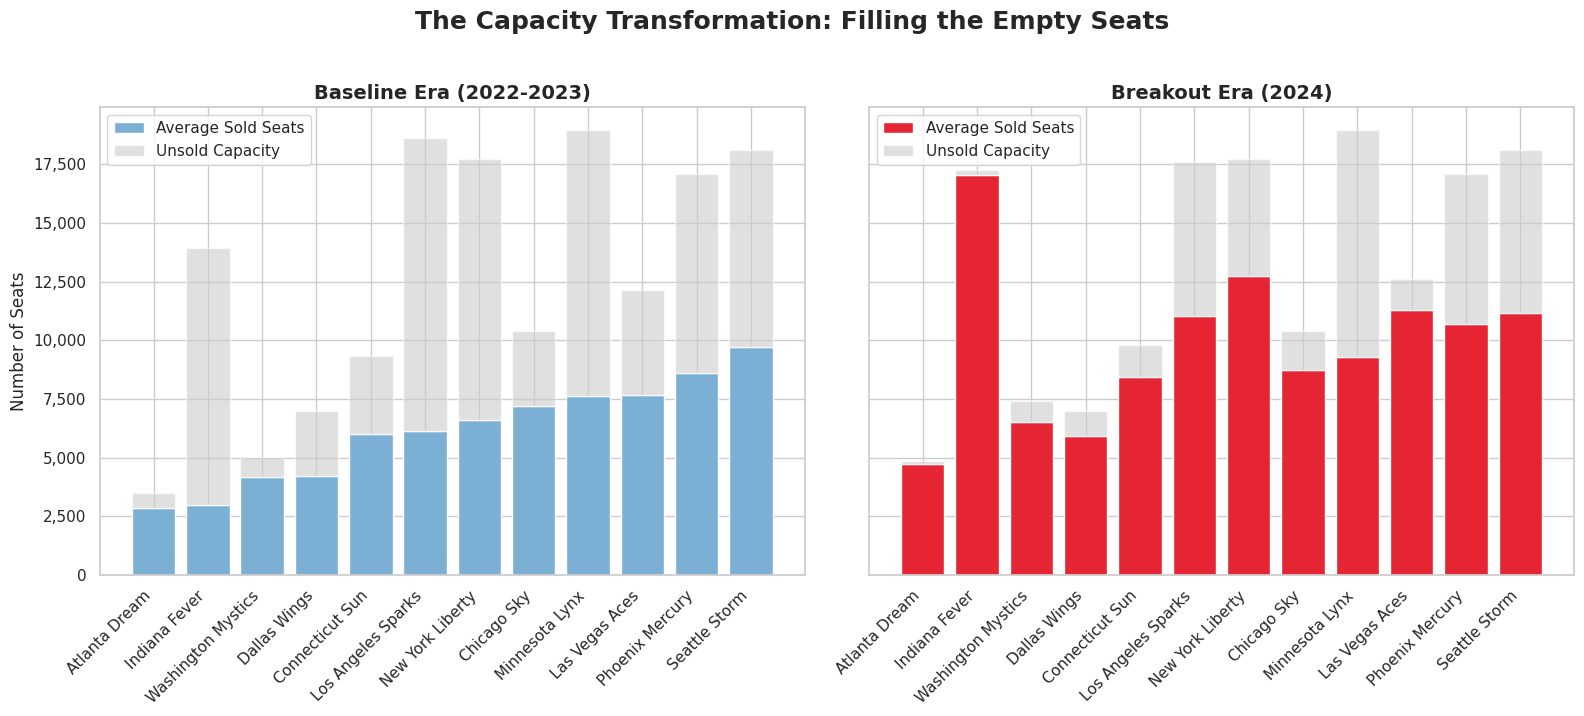

In [ ]:
# ==============================================================================
# CHART 3: The Capacity Transformation (Side-by-Side Stacked Bars)
# Visualizing the baseline environment (22-23) vs the breakout (24)
# ==============================================================================
print("Generating Chart 3: The Capacity Transformation...")

# --- 1. Prep Baseline Data (2022-2023) ---
df_base = unified_df_five_years[unified_df_five_years['season'].astype(str).isin(['2022', '2023'])].copy()
cap_base = df_base.groupby('home_team_name').agg(
    avg_attendance=('attendance', 'mean'),
    avg_capacity=('base_arena_capacity', 'mean')
).reset_index()

cap_base['empty_seats'] = cap_base['avg_capacity'] - cap_base['avg_attendance']
# Sort teams by baseline attendance so both charts have the same X-axis order
cap_base = cap_base.sort_values('avg_attendance', ascending=True)
team_order = cap_base['home_team_name'].tolist()

# --- 2. Prep Breakout Data (2024) ---
df_2024 = unified_df_five_years[unified_df_five_years['season'].astype(str) == '2024'].copy()
cap_2024 = df_2024.groupby('home_team_name').agg(
    avg_attendance=('attendance', 'mean'),
    avg_capacity=('base_arena_capacity', 'mean')
).reset_index()

cap_2024['empty_seats'] = cap_2024['avg_capacity'] - cap_2024['avg_attendance']
# Force the 2024 data to match the sorting order of the baseline data
cap_2024['home_team_name'] = pd.Categorical(cap_2024['home_team_name'], categories=team_order, ordered=True)
cap_2024 = cap_2024.sort_values('home_team_name')

# --- 3. Plotting Side-by-Side ---
# sharey=True is critical here so the visual scale remains honest across both eras
fig3, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Plot A: Baseline Era
axes[0].bar(cap_base['home_team_name'], cap_base['avg_attendance'], label='Average Sold Seats', color='#7bafd4')
axes[0].bar(cap_base['home_team_name'], cap_base['empty_seats'], bottom=cap_base['avg_attendance'], label='Unsold Capacity', color='#cccccc', alpha=0.6)
axes[0].set_title("Baseline Era (2022-2023)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Number of Seats", fontsize=12)

# Plot B: Breakout Era
axes[1].bar(cap_2024['home_team_name'], cap_2024['avg_attendance'], label='Average Sold Seats', color='#e52534')
axes[1].bar(cap_2024['home_team_name'], cap_2024['empty_seats'], bottom=cap_2024['avg_attendance'], label='Unsold Capacity', color='#cccccc', alpha=0.6)
axes[1].set_title("Breakout Era (2024)", fontsize=14, fontweight='bold')

# Formatting for both axes
for ax in axes:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))
    ax.set_xticks(range(len(team_order)))
    ax.set_xticklabels(team_order, rotation=45, ha='right')
    ax.legend(loc='upper left')

# Super Title for the whole figure
fig3.suptitle("The Capacity Transformation: Filling the Empty Seats", fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

Generating Chart 3: The Capacity Transformation...


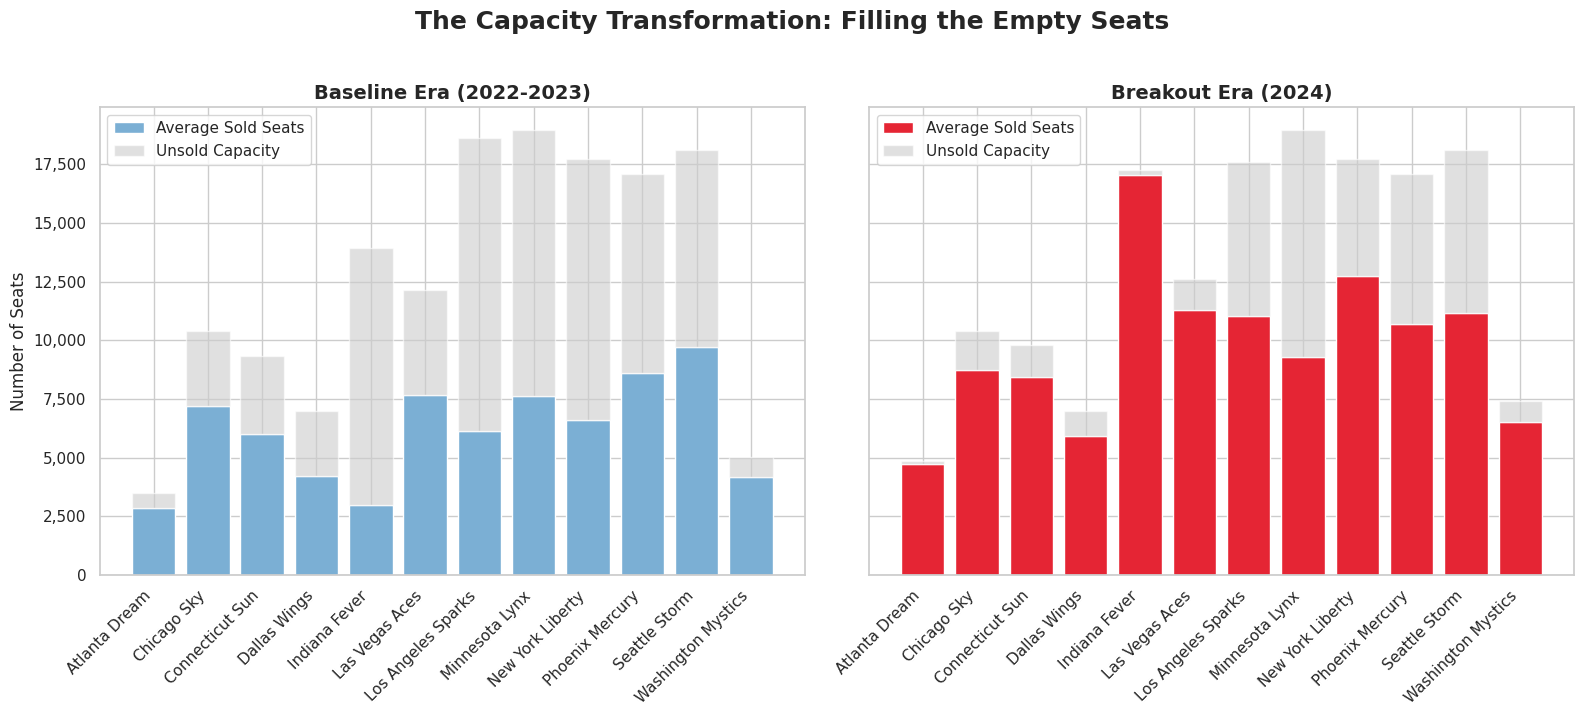

In [ ]:
# ==============================================================================
# CHART 3: The Capacity Transformation (Side-by-Side Stacked Bars)
# Visualizing the baseline environment (22-23) vs the breakout (24)
# ==============================================================================
print("Generating Chart 3: The Capacity Transformation...")

# --- 1. Prep Baseline Data (2022-2023) ---
df_base = unified_df_five_years[unified_df_five_years['season'].astype(str).isin(['2022', '2023'])].copy()
cap_base = df_base.groupby('home_team_name').agg(
    avg_attendance=('attendance', 'mean'),
    avg_capacity=('base_arena_capacity', 'mean')
).reset_index()

cap_base['empty_seats'] = cap_base['avg_capacity'] - cap_base['avg_attendance']
# Sort teams alphabetically so both charts have the same A-Z X-axis order
cap_base = cap_base.sort_values('home_team_name', ascending=True)
team_order = cap_base['home_team_name'].tolist()

# --- 2. Prep Breakout Data (2024) ---
df_2024 = unified_df_five_years[unified_df_five_years['season'].astype(str) == '2024'].copy()
cap_2024 = df_2024.groupby('home_team_name').agg(
    avg_attendance=('attendance', 'mean'),
    avg_capacity=('base_arena_capacity', 'mean')
).reset_index()

cap_2024['empty_seats'] = cap_2024['avg_capacity'] - cap_2024['avg_attendance']
# Force the 2024 data to match the alphabetical sorting order of the baseline data
cap_2024['home_team_name'] = pd.Categorical(cap_2024['home_team_name'], categories=team_order, ordered=True)
cap_2024 = cap_2024.sort_values('home_team_name')

# --- 3. Plotting Side-by-Side ---
# sharey=True is critical here so the visual scale remains honest across both eras
fig3, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Plot A: Baseline Era
axes[0].bar(cap_base['home_team_name'], cap_base['avg_attendance'], label='Average Sold Seats', color='#7bafd4')
axes[0].bar(cap_base['home_team_name'], cap_base['empty_seats'], bottom=cap_base['avg_attendance'], label='Unsold Capacity', color='#cccccc', alpha=0.6)
axes[0].set_title("Baseline Era (2022-2023)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Number of Seats", fontsize=12)

# Plot B: Breakout Era
axes[1].bar(cap_2024['home_team_name'], cap_2024['avg_attendance'], label='Average Sold Seats', color='#e52534')
axes[1].bar(cap_2024['home_team_name'], cap_2024['empty_seats'], bottom=cap_2024['avg_attendance'], label='Unsold Capacity', color='#cccccc', alpha=0.6)
axes[1].set_title("Breakout Era (2024)", fontsize=14, fontweight='bold')

# Formatting for both axes
for ax in axes:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))
    ax.set_xticks(range(len(team_order)))
    ax.set_xticklabels(team_order, rotation=45, ha='right')
    ax.legend(loc='upper left')

# Super Title for the whole figure
fig3.suptitle("The Capacity Transformation: Filling the Empty Seats", fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CHART 3: The Capacity Transformation (Side-by-Side Stacked Bars)
# Visualizing the baseline environment (22-23) vs the breakout (24)
# ==============================================================================
print("Generating Chart 3: The Capacity Transformation...")

# --- 1. Prep Baseline Data (2022-2023) ---
df_base = unified_df_five_years[unified_df_five_years['season'].astype(str).isin(['2022', '2023'])].copy()
cap_base = df_base.groupby('home_team_name').agg(
    avg_attendance=('attendance', 'mean'),
    avg_capacity=('base_arena_capacity', 'mean')
).reset_index()

cap_base['empty_seats'] = cap_base['avg_capacity'] - cap_base['avg_attendance']
# Sort teams by baseline attendance so both charts have the same X-axis order
cap_base = cap_base.sort_values('avg_attendance', ascending=True)
team_order = cap_base['home_team_name'].tolist()

# --- 2. Prep Breakout Data (2024) ---
df_2024 = unified_df_five_years[unified_df_five_years['season'].astype(str) == '2024'].copy()
cap_2024 = df_2024.groupby('home_team_name').agg(
    avg_attendance=('attendance', 'mean'),
    avg_capacity=('base_arena_capacity', 'mean')
).reset_index()

cap_2024['empty_seats'] = cap_2024['avg_capacity'] - cap_2024['avg_attendance']
# Force the 2024 data to match the sorting order of the baseline data
cap_2024['home_team_name'] = pd.Categorical(cap_2024['home_team_name'], categories=team_order, ordered=True)
cap_2024 = cap_2024.sort_values('home_team_name')

# --- 3. Plotting Side-by-Side ---
# sharey=True is critical here so the visual scale remains honest across both eras
fig3, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Plot A: Baseline Era
axes[0].bar(cap_base['home_team_name'], cap_base['avg_attendance'], label='Average Sold Seats', color='#7bafd4')
axes[0].bar(cap_base['home_team_name'], cap_base['empty_seats'], bottom=cap_base['avg_attendance'], label='Unsold Capacity', color='#cccccc', alpha=0.6)
axes[0].set_title("Baseline Era (2022-2023)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Number of Seats", fontsize=12)

# Plot B: Breakout Era
axes[1].bar(cap_2024['home_team_name'], cap_2024['avg_attendance'], label='Average Sold Seats', color='#e52534')
axes[1].bar(cap_2024['home_team_name'], cap_2024['empty_seats'], bottom=cap_2024['avg_attendance'], label='Unsold Capacity', color='#cccccc', alpha=0.6)
axes[1].set_title("Breakout Era (2024)", fontsize=14, fontweight='bold')

# Formatting for both axes
for ax in axes:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))
    ax.set_xticks(range(len(team_order)))
    ax.set_xticklabels(team_order, rotation=45, ha='right')
    ax.legend(loc='upper left')

# Super Title for the whole figure
fig3.suptitle("The Capacity Transformation: Filling the Empty Seats", fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Raw Data Visualizations

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load the raw dataset
df_raw = pd.read_csv('unified_2021_2025.csv')
df_raw['season'] = df_raw['season'].astype(str)

# 2. Clean and Filter (DROP 2021 COVID SEASON)
df_eda = df_raw[(df_raw['attendance'] > 0) & (df_raw['season'] != '2021')].copy()

# 3. Create an 'Era' feature to easily compare Pre-Breakout vs Post-Breakout
df_eda['Era'] = np.where(df_eda['season'].isin(['2022', '2023']), 'Baseline (2022-23)', 'Breakout (2024-25)')

# Recalculate 'is_camp_day' for the EDA
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
camp_time_pattern = '10:.*AM|11:.*AM|12:.*PM|1:.*PM|2:.*PM|3:.*PM'
df_eda['is_camp_day'] = (
    (df_eda['day_of_week'].isin(weekdays)) &
    (df_eda['time_et'].str.contains(camp_time_pattern, na=False))
).astype(int)

# =====================================================================
# CHART 1: The Paradigm Shift (Average Attendance by Season)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_eda, x='season', y='attendance', hue='Era',
    dodge=False, estimator=np.mean, errorbar=None, palette=['#7bafd4', '#e52534'], ax=ax1
)
ax1.set_title("WNBA Average Per-Game Attendance", fontsize=16, fontweight='bold')
ax1.set_xlabel("Season", fontsize=12)
ax1.set_ylabel("Average Attendance", fontsize=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Add data labels
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')
plt.legend(title="WNBA Era")
plt.tight_layout()
plt.savefig("eda_1_paradigm_shift.png", dpi=300)
plt.show()

# =====================================================================
# CHART 2: Hitting the Ceiling (Arena Fill Rate by Era)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(12, 6))
# Calculate fill rate if not already perfect in the CSV
df_eda['fill_rate'] = df_eda['attendance'] / df_eda['base_arena_capacity']

sns.violinplot(
    data=df_eda, x='season', y='fill_rate', hue='Era',
    palette=['#7bafd4', '#e52534'], split=False, inner="quartile", ax=ax2
)
ax2.axhline(1.0, color='black', linestyle='--', linewidth=2, label='100% Capacity')

ax2.set_title("2. Hitting the Ceiling: Arena Fill Rates by Season", fontsize=16, fontweight='bold')
ax2.set_xlabel("Season", fontsize=12)
ax2.set_ylabel("Arena Fill Rate (% of Capacity)", fontsize=12)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("eda_2_hitting_ceiling.png", dpi=300)
plt.show()

# =====================================================================
# CHART 3: The Traveling Circus (Road Attendance by Visiting Team)
# =====================================================================
fig3, ax3 = plt.subplots(figsize=(12, 8))

# Sort by the highest drawing road teams in the Breakout Era
road_draws = df_eda.groupby(['away_team_name', 'Era'])['attendance'].mean().reset_index()
order = road_draws[road_draws['Era'] == 'Breakout (2024-25)'].sort_values('attendance', ascending=False)['away_team_name']

sns.barplot(
    data=df_eda, y='away_team_name', x='attendance', hue='Era',
    order=order, estimator=np.mean, errorbar=None, palette=['#7bafd4', '#e52534'], ax=ax3
)
ax3.set_title("3. The Traveling Circus: Average Road Attendance by Visiting Team", fontsize=16, fontweight='bold')
ax3.set_xlabel("Average Road Attendance", fontsize=12)
ax3.set_ylabel("Visiting Team", fontsize=12)
ax3.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.legend(title="WNBA Era", loc='lower right')
plt.tight_layout()
plt.savefig("eda_3_traveling_circus.png", dpi=300)
plt.show()

# =====================================================================
# CHART 4: Camp Days vs Standard Games (The Scheduling Effect)
# =====================================================================
fig4, ax4 = plt.subplots(figsize=(10, 6))

df_eda['Game Type'] = np.where(df_eda['is_camp_day'] == 1, 'Camp Day (Weekday Morning/Afternoon)', 'Standard Game')

sns.boxplot(
    data=df_eda, x='Era', y='attendance', hue='Game Type',
    palette="Set2", ax=ax4
)
ax4.set_title("4. The Scheduling Effect: Camp Days vs Standard Games", fontsize=16, fontweight='bold')
ax4.set_xlabel("WNBA Era", fontsize=12)
ax4.set_ylabel("Attendance", fontsize=12)
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("eda_4_camp_days.png", dpi=300)
plt.show()

# =====================================================================
# CHART 5: Redefining Ticket Demand (Win % vs. Attendance)
# =====================================================================
fig5, ax5 = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df_eda, x='opponent_win_pct', y='attendance', hue='Era',
    palette=['#7bafd4', '#e52534'], alpha=0.7, s=70, edgecolor='black', ax=ax5
)

ax5.set_title("5. Redefining Demand: Does the Opponent's Record Matter Anymore?", fontsize=16, fontweight='bold')
ax5.set_xlabel("Visiting Team Win Percentage", fontsize=12)
ax5.set_ylabel("Actual Attendance", fontsize=12)
ax5.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.legend(title="WNBA Era")
plt.tight_layout()
plt.savefig("eda_5_win_pct_shift.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load the raw dataset
df_raw = pd.read_csv('unified_2021_2025.csv')
df_raw['season'] = df_raw['season'].astype(str)
df_raw['game_date'] = pd.to_datetime(df_raw['game_date'])

# 2. Clean and Filter (KEEP ONLY 2022, 2023, and 2024)
df_clean = df_raw[(df_raw['attendance'] > 0) & (df_raw['season'].isin(['2022', '2023', '2024']))].copy()

# 3. Engineer and DROP Camp Days (Focus strictly on baseline demand)
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
camp_time_pattern = '10:.*AM|11:.*AM|12:.*PM|1:.*PM|2:.*PM|3:.*PM'
df_clean['is_camp_day'] = (
    (df_clean['day_of_week'].isin(weekdays)) &
    (df_clean['time_et'].str.contains(camp_time_pattern, na=False))
).astype(int)

# 🌟 Filter down to ONLY Standard Baseline Games (No Camp Days)
df_baseline = df_clean[df_clean['is_camp_day'] == 0].copy()

# Create Era column for comparison
df_baseline['Era'] = np.where(df_baseline['season'].isin(['2022', '2023']), 'Baseline Era (2022-23)', 'Breakout Era (2024)')


# =====================================================================
# CHART 1: The Paradigm Shift (BAR PLOT)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_baseline, x='season', y='attendance', hue='Era',
    dodge=False, estimator=np.mean, errorbar=None, palette=['#7bafd4', '#e52534'], ax=ax1
)
ax1.set_title("1. Baseline Ticket Demand by Season (Bar Plot)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Season", fontsize=12)
ax1.set_ylabel("Average Standard-Game Attendance", fontsize=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Add data labels
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')
plt.legend(title="WNBA Era", loc='upper left')
plt.tight_layout()
plt.savefig("trend_1_bar_2024.png", dpi=300)
plt.show()

# =====================================================================
# CHART 2: The Paradigm Shift (LINE PLOT - Rolling Monthly Average)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Group by Year and Month to show a continuous timeline
df_baseline['year_month'] = df_baseline['game_date'].dt.to_period('M')
monthly_trend = df_baseline.groupby('year_month')['attendance'].mean().reset_index()
monthly_trend['year_month'] = monthly_trend['year_month'].dt.to_timestamp()

ax2.plot(monthly_trend['year_month'], monthly_trend['attendance'], marker='o', linestyle='-', color='#2ca02c', linewidth=3, markersize=8)
ax2.fill_between(monthly_trend['year_month'], monthly_trend['attendance'], color='#2ca02c', alpha=0.2)

ax2.set_title("2. Baseline Ticket Demand Over Time (Line Plot)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Timeline (Month & Year)", fontsize=12)
ax2.set_ylabel("Average Monthly Attendance", fontsize=12)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Add a vertical line when the 2024 season started (The "Clark/Reese" entry point)
start_of_2024 = pd.to_datetime('2024-05-14')
ax2.axvline(start_of_2024, color='red', linestyle='--', linewidth=2, label='Start of 2024 Breakout Era')
plt.legend()
plt.tight_layout()
plt.savefig("trend_2_line_2024.png", dpi=300)
plt.show()

# =====================================================================
# CHART 3: The Paradigm Shift (SCATTER PLOT - Every Single Game)
# =====================================================================
fig3, ax3 = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df_baseline, x='game_date', y='attendance', hue='Era',
    palette=['#7bafd4', '#e52534'], alpha=0.6, s=60, edgecolor=None, ax=ax3
)

ax3.set_title("3. Baseline Ticket Demand Game-by-Game (Scatter Plot)", fontsize=16, fontweight='bold')
ax3.set_xlabel("Game Date", fontsize=12)
ax3.set_ylabel("Actual Attendance", fontsize=12)
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Add a smooth trendline (LOWESS) through the scatter dots
sns.regplot(
    data=df_baseline, x=df_baseline['game_date'].map(pd.Timestamp.toordinal), y='attendance',
    scatter=False, lowess=True, color='black', line_kws={'linewidth': 3, 'linestyle': '--'}, ax=ax3
)

plt.legend(title="WNBA Era", loc='upper left')
plt.tight_layout()
plt.savefig("trend_3_scatter_2024.png", dpi=300)
plt.show()

# =====================================================================
# CHART 4: Home Team Growth (Grouped Bar Chart)
# =====================================================================
fig4, ax4 = plt.subplots(figsize=(14, 8))

# Sort home teams by their Breakout Era (2024) attendance
home_draws = df_baseline.groupby(['home_team_name', 'Era'])['attendance'].mean().reset_index()
order = home_draws[home_draws['Era'] == 'Breakout Era (2024)'].sort_values('attendance', ascending=False)['home_team_name']

sns.barplot(
    data=df_baseline, x='home_team_name', y='attendance', hue='Era',
    order=order, estimator=np.mean, errorbar=None, palette=['#7bafd4', '#e52534'], ax=ax4
)

ax4.set_title("4. Franchise Value: Average Home Attendance Growth by Team (22-23 vs 24)", fontsize=16, fontweight='bold')
ax4.set_xlabel("Home Team (The Beneficiary)", fontsize=12)
ax4.set_ylabel("Average Standard-Game Attendance", fontsize=12)
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.xticks(rotation=45, ha='right')
plt.legend(title="WNBA Era", loc='upper right')
plt.tight_layout()
plt.savefig("trend_4_home_teams_2024.png", dpi=300)
plt.show()

# DIFF IN DIFF

In [ ]:
df_pre_full = unified_df_five_years[
    unified_df_five_years["season"].astype(str).isin(["2022", "2023"])
].copy()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. PREP DATA
# =========================================================

pre = df_pre_full
post = df_future_w.copy()

# Standardize date + month
for df in [pre, post]:
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
    df["game_month"] = df["game_date"].dt.month.astype("Int64").astype(str)
    df["season"] = df["season"].astype(str)

# =========================================================
# 2. CREATE DiD VARIABLES
# =========================================================

pre["post"] = 0
post["post"] = 1

# Treatment = Indiana Fever games
for df in [pre, post]:
    df["treated"] = (
        (df["home_team_name"] == "Indiana Fever") |
        (df["away_team_name"] == "Indiana Fever")
    ).astype(int)

# Combine
did_df = pd.concat([pre, post], ignore_index=True)

# Clean
# Fill missing controls instead of dropping rows
for col in ["arena_capacity", "market_size", "opponent_win_pct"]:
    did_df[col] = did_df[col].fillna(did_df[col].median())

# Interaction
did_df["did"] = did_df["treated"] * did_df["post"]

# =========================================================
# 3. DROP MISSING
# =========================================================

needed_cols = [
    "attendance",
    "treated",
    "post",
    "did",
    "arena_capacity",
    "market_size",
    "opponent_win_pct",
    "day_of_week",
    "game_month"
]

# =========================================================
# 4. RUN DiD REGRESSION (STRONG SPEC)
# =========================================================

formula = """
attendance ~ did
           + arena_capacity + market_size + opponent_win_pct
           + C(day_of_week) + C(game_month)
           + C(home_team_name)
"""

model = smf.ols(formula=formula, data=did_df).fit(cov_type="HC1")

print("=" * 80)
print("CAITLIN CLARK DiD RESULTS")
print("=" * 80)
print(model.summary())

# Key result
effect = model.params["did"]
pval = model.pvalues["did"]
ci_low, ci_high = model.conf_int().loc["did"]

print("\n" + "=" * 80)
print("KEY RESULT")
print("=" * 80)
print(f"Clark effect: {effect:,.0f} fans per game")
print(f"p-value: {pval:.4f}")
print(f"95% CI: [{ci_low:,.0f}, {ci_high:,.0f}]")

# =========================================================
# 5. GROUP MEANS (SAFE VERSION)
# =========================================================

group_means = (
    did_df.groupby(["post", "treated"], as_index=False)["attendance"]
    .mean()
)

group_means["Period"] = group_means["post"].map({0: "Pre-Clark", 1: "Post-Clark"})
group_means["Group"] = group_means["treated"].map({0: "Other Games", 1: "Fever Games"})

print("\nGROUP MEANS:")
print(group_means[["Period", "Group", "attendance"]].to_string(index=False))

# Safe pivot
pivot = group_means.pivot(index="post", columns="treated", values="attendance")

if set(pivot.index) >= {0,1} and set(pivot.columns) >= {0,1}:
    manual_did = (pivot.loc[1,1] - pivot.loc[0,1]) - (pivot.loc[1,0] - pivot.loc[0,0])
    print(f"\nManual DiD check: {manual_did:,.0f} fans per game")
else:
    print("\nWARNING: Missing one of the 4 DiD cells")

# =========================================================
# 6. PRETTY DiD PLOT (POSTER READY)
# =========================================================

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(8,6))

ax = sns.lineplot(
    data=group_means,
    x="Period",
    y="attendance",
    hue="Group",
    style="Group",
    markers=True,
    dashes=False,
    linewidth=3,
    markersize=10,
    palette={
        "Other Games": "#6c757d",
        "Fever Games": "#e63946"
    }
)

plt.title("Caitlin Clark Impact: Difference-in-Differences", pad=15)
plt.ylabel("Average Attendance")
plt.xlabel("")

# Labels
for _, row in group_means.iterrows():
    x_pos = 0 if row["Period"] == "Pre-Clark" else 1
    plt.text(
        x=x_pos,
        y=row["attendance"] + 150,
        s=f'{row["attendance"]:,.0f}',
        ha="center",
        fontsize=11
    )

sns.despine()
plt.show()